# Benchmarks SoTA + TSCS effect

In [1]:
# === SETUP: Run this first! ===
import os
import sys

# Change to project root and add to Python path
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Goes up one level from 'notebooks/'
os.chdir(project_root)
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"tsnn module path: {os.path.join(project_root, 'tsnn')}")

Project root: /Users/cyrilgarcia/notebooks/tsnn
tsnn module path: /Users/cyrilgarcia/notebooks/tsnn/tsnn


In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn import tstorch
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
from tsnn.tstorch import transformers
import torch.nn.functional as F
import math
from typing import Optional

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from torch import nn
from tqdm import tqdm
device = 'mps'


plt.style.use('ggplot')

In [3]:
# This is the new version of the notebook to make all the figures for the paper.

In [4]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

In [5]:
# Notebook to run all the experiments for the paper.

In [6]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool

In [7]:
def get_ols_corr(N_fea, T_train, rho, oos=True):
    ratio = N_fea/T_train
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)


In [8]:
def keep_topk_per_row3(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [9]:
def keep_by_max_value2(x, frac=0.2):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out

def keep_by_max_value1(x, frac=0.1):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out


In [10]:
def run_models1(rhos, effect, T=4000, n_ts=10, n_f=5, n_rolling=10):

    list_effects1 = [effect]*n_f

    if n_f >=10:
        half_n_f = int(n_f/2)
        correl_split_by_fea1 = [1/np.sqrt(half_n_f)]*(half_n_f) + [0]*half_n_f 
    else:
        correl_split_by_fea1 = [1/np.sqrt(n_f)]*n_f

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []

    for (i,rho) in enumerate(rhos):
        print("Running correl level:", rho)
        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


        z.generate_dataset_gr_simple(
            global_corr=rho, 
            correl_split_by_fea=correl_split_by_fea1, 
            list_type_effects=list_effects1,
            list_type_interaction=["cond"], 
            random_ts_shift=n_rolling,
        )
        z.get_dataloader(n_rolling=n_rolling)

        lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                                verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
        lasso_full.fit(z.train)
        boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))
        boost_model.fit(z.train)

        comp = benchmark_comparison.Comparator(models=[lasso_full, boost_model], model_names=['lasso_full', 'boosting'])
        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        # Save results
        res_train.append({
            "rho": rhos[i],
            "model": 'Lasso',
            "train_corr_optimal": corr_train.loc['lasso_full', "optimal"]
        })
        res_test.append({
            "rho": rhos[i],
            "model": 'Lasso',
            "test_corr_optimal": corr_test.loc['lasso_full', "optimal"]
        })

        res_train.append({
            "rho": rhos[i],
            "model": 'Boosting',
            "train_corr_optimal": corr_train.loc['boosting', "optimal"]
        })
        res_test.append({
            "rho": rhos[i],
            "model": 'Boosting',
            "test_corr_optimal": corr_test.loc['boosting', "optimal"]
        })

        models_torch = {                 
        'Global_MLP': models.GlobalMLP(n_ts, n_f, n_rolling, dropout=0.1).to(device),          
        # '2D_Trans_TC': models.CustomBiDimensionalTransformer(
        #     n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
        #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        # ).to(device),
        '2D_Trans_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),      
        # '2D_Trans_TC_sparse': models.CustomBiDimensionalTransformer(
        #     n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
        #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_topk_per_row3, roll_y=True, embeddings="both",
        # ).to(device),
        # '2D_Trans_TCTC_sparse1': models.CustomBiDimensionalTransformer(
        #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
        #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_topk_per_row3, roll_y=True, embeddings="both",
        # ).to(device),
        #  '2D_Trans_TCTC_spar_max01': models.CustomBiDimensionalTransformer(
        #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
        #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_by_max_value1, roll_y=True, embeddings="both",
        # ).to(device),
        #  '2D_Trans_TCTC_spar_max02': models.CustomBiDimensionalTransformer(
        #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
        #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_by_max_value2, roll_y=True, embeddings="both",
        # ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }

        
        for k in models_torch:
            roll_y = True
            if k in ['Global_MLP']:
                roll_y = False
            z.get_dataloader(n_rolling=n_rolling, roll_y=roll_y)
            epochs=40
            models_torch[k].fit(z.train, test=z.test, epochs=epochs, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test

## n_f = 5

In [11]:
all_effects_nf5_train_dic = {}
all_effects_nf5_test_dic = {}

In [12]:
#for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
# for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift']:
for effect in ['TS_shift']:
    print("Running_effect:", effect)
    # out_train1, out_test1 = run_models1([0.02, 0.05, 0.1, 0.2, 0.5], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    out_train1, out_test1 = run_models1([0.02, 0.1], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    all_effects_nf5_train_dic[effect] = out_train1
    all_effects_nf5_test_dic[effect] = out_test1

Running_effect: TS_shift
Running correl level: 0.02
Running correl level: 0.1


In [13]:
# for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift']:
for effect in ['TS_shift']:
    print(effect)
    display(all_effects_nf5_train_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(all_effects_nf5_test_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

TS_shift


rho,0.020000,0.100000
model,,
2D_Trans_TCTC,0.026,0.120
Boosting,0.056,0.286
Global_MLP,0.029,0.110
Lasso,0.279,0.934
theo_correl,0.045,0.219


rho,0.020000,0.100000
model,,
2D_Trans_TCTC,0.016,0.103
Boosting,0.064,0.374
Global_MLP,0.043,0.172
Lasso,0.279,0.932
theo_correl,0.040,0.197


In [14]:
all_effects_nf5_train_dic = {}
all_effects_nf5_test_dic = {}

In [15]:
#for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
# for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift']:
for effect in ['CS_shift']:
    print("Running_effect:", effect)
    # out_train1, out_test1 = run_models1([0.02, 0.05, 0.1, 0.2, 0.5], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    out_train1, out_test1 = run_models1([0.02, 0.1], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    all_effects_nf5_train_dic[effect] = out_train1
    all_effects_nf5_test_dic[effect] = out_test1

Running_effect: CS_shift
Running correl level: 0.02
Running correl level: 0.1


In [16]:
# for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift']:
for effect in ['CS_shift']:
    print(effect)
    display(all_effects_nf5_train_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(all_effects_nf5_test_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

CS_shift


rho,0.020000,0.100000
model,,
2D_Trans_TCTC,0.127,0.278
Boosting,0.018,0.083
Global_MLP,0.033,0.097
Lasso,0.024,0.173
theo_correl,0.045,0.219


rho,0.020000,0.100000
model,,
2D_Trans_TCTC,0.101,0.259
Boosting,-0.005,0.023
Global_MLP,0.058,0.159
Lasso,0.006,0.176
theo_correl,0.040,0.197


In [17]:
#for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
# for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift']:
for effect in ['TSCS_shift']:
    print("Running_effect:", effect)
    # out_train1, out_test1 = run_models1([0.02, 0.05, 0.1, 0.2, 0.5], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    out_train1, out_test1 = run_models1([0.02, 0.1], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    all_effects_nf5_train_dic[effect] = out_train1
    all_effects_nf5_test_dic[effect] = out_test1

Running_effect: TSCS_shift
Running correl level: 0.02
Running correl level: 0.1


In [19]:
# for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift']:
for effect in ['TSCS_shift']:
    print(effect)
    display(all_effects_nf5_train_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(all_effects_nf5_test_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

TSCS_shift


rho,0.020000,0.100000
model,,
2D_Trans_TCTC,0.002,0.044
Boosting,0.018,0.099
Global_MLP,0.021,0.109
Lasso,-0.002,0.186
theo_correl,0.045,0.219


rho,0.020000,0.100000
model,,
2D_Trans_TCTC,-0.001,-0.003
Boosting,0.007,0.047
Global_MLP,0.035,0.151
Lasso,-0.010,0.187
theo_correl,0.040,0.197


## Diagnostic: focus on `TCTC` only

This section reuses the same `run_models1(...)` setup as the notebook above and only keeps the `2D_Trans_TCTC` results.
The goal is to compare `TS_shift`, `CS_shift`, and `TSCS_shift` without changing the training or evaluation pipeline.


In [ ]:
def run_tctc_effect_diagnostic(
    effects=('TS_shift', 'CS_shift', 'TSCS_shift'),
    rhos=(0.02, 0.1),
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
):
    results = []
    full_train = {}
    full_test = {}

    for effect in effects:
        out_train, out_test = run_models1(
            list(rhos),
            effect,
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            n_rolling=n_rolling,
        )

        full_train[effect] = out_train
        full_test[effect] = out_test

        for rho in rhos:
            results.append({
                'effect': effect,
                'rho': rho,
                'train_corr_optimal': out_train.loc[rho, '2D_Trans_TCTC'],
                'test_corr_optimal': out_test.loc[rho, '2D_Trans_TCTC'],
            })

    return pd.DataFrame(results), full_train, full_test


tctc_diag_results, tctc_diag_train_tables, tctc_diag_test_tables = run_tctc_effect_diagnostic()


In [29]:
display(tctc_diag_results.style.format(precision=3))
display(tctc_diag_results.pivot(index='effect', columns='rho', values='train_corr_optimal').style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tctc_diag_results.pivot(index='effect', columns='rho', values='test_corr_optimal').style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))


,effect,rho,train_corr_optimal,test_corr_optimal
0,TS_shift,0.020,0.010,0.005
1,TS_shift,0.100,0.150,0.096
2,CS_shift,0.020,0.044,0.056
3,CS_shift,0.100,0.197,0.181
4,TSCS_shift,0.020,0.007,-0.004
5,TSCS_shift,0.100,0.034,-0.006


rho,0.020000,0.100000
effect,,
CS_shift,0.044,0.197
TSCS_shift,0.007,0.034
TS_shift,0.010,0.150


rho,0.020000,0.100000
effect,,
CS_shift,0.056,0.181
TSCS_shift,-0.004,-0.006
TS_shift,0.005,0.096


## Generator-based TCTC diagnostics

This section now reuses the project generator instead of a custom synthetic helper.
We compare `TS_shift`, `CS_shift`, and `TSCS_shift` under the exact same data-generation path as the rest of the notebook.


In [11]:
def _default_corr_split(n_f):
    if n_f >= 10:
        half_n_f = int(n_f / 2)
        return [1 / np.sqrt(half_n_f)] * half_n_f + [0] * half_n_f
    return [1 / np.sqrt(n_f)] * n_f


def generate_project_generator_dataset(
    effect='TSCS_shift',
    T=4000,
    n_ts=10,
    n_f=5,
    rho=0.1,
    n_rolling=10,
    seed=0,
    shuffle_cs=True,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    z = generators.Generator(T, n_ts, n_f)
    z.generate_dataset_gr_simple(
        global_corr=rho,
        correl_split_by_fea=_default_corr_split(n_f),
        list_type_effects=[effect] * n_f,
        list_type_interaction=['cond'],
        random_ts_shift=n_rolling,
        shuffle_cs=shuffle_cs,
    )

    return z.X, z.y, z.ys['optimal'], z


def build_loaders_from_tensors(X, y, n_rolling=10, batch_size=256, train_pct=0.625, train_shuffle=True, test_shuffle=False, roll_y=True):
    dataset = utils.TorchDatasetRolling(X, y, n=n_rolling, roll_y=roll_y)
    train_size = int(train_pct * len(dataset))

    train_data = torch.utils.data.Subset(dataset, range(train_size))
    test_data = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=train_shuffle, collate_fn=utils.collate_pad_beginning)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=test_shuffle, collate_fn=utils.collate_pad_beginning)

    return train_loader, test_loader


def corr_to_optimal(model_wrapper, dataloader, y_opt):
    preds = []
    model_wrapper.model.eval()

    eval_loader = DataLoader(
        dataloader.dataset,
        batch_size=dataloader.batch_size,
        shuffle=False,
        collate_fn=dataloader.collate_fn,
    )

    with torch.no_grad():
        for batch in eval_loader:
            if len(batch) == 3:
                X, _, pad_mask = batch
                pred = model_wrapper.model(X.to(device), pad_mask=pad_mask.to(device)).detach().cpu()
            else:
                X, _ = batch
                pred = model_wrapper.model(X.to(device)).detach().cpu()

            if pred.ndim == 3:
                pred = pred[:, -1, :]
            preds.append(pred.flatten())

    preds = torch.cat(preds).numpy()
    idx = dataloader.dataset.indices
    target = y_opt[idx].reshape(-1).numpy()

    return np.corrcoef(preds, target)[0][1]


def run_tctc_tscs_ablation(
    rhos=(0.1, 0.3),
    effects=('TS_shift', 'CS_shift', 'TSCS_shift'),
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
    epochs=20,
    batch_size=256,
    seed=0,
):
    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    results = []

    for effect in effects:
        for rho in rhos:
            X, y, y_opt, _ = generate_project_generator_dataset(
                effect=effect,
                T=T,
                n_ts=n_ts,
                n_f=n_f,
                rho=rho,
                n_rolling=n_rolling,
                seed=seed,
            )

            train_loader, test_loader = build_loaders_from_tensors(
                X, y, n_rolling=n_rolling, batch_size=batch_size
            )

            model = models.CustomBiDimensionalTransformer(
                n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
                dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None,
                roll_y=True, embeddings='both',
            ).to(device)

            wrapper = torch_benchmarks.TorchWrapper(
                model,
                optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
                loss_fn=nn.MSELoss(),
                device=device,
            )

            wrapper.fit(train_loader, test=test_loader, epochs=epochs, plot=False, verbose=0)

            results.append({
                'effect': effect,
                'rho': rho,
                'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
                'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
                'last_train_batch_corr': wrapper.train_corr[-1],
                'last_test_batch_corr': wrapper.test_corr[-1],
            })

    return pd.DataFrame(results)


In [ ]:
tctc_tscs_ablation = run_tctc_tscs_ablation(rhos=(0.1, 0.3), epochs=20, T=4000, n_ts=10, n_f=5, n_rolling=10)
display(tctc_tscs_ablation.style.format(precision=3))
display(tctc_tscs_ablation.pivot(index='effect', columns='rho', values='test_corr_optimal').style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))


## Joint spatiotemporal attention vs TCTC

This section uses the project generator directly.
The goal is to compare the factorized `TCTC` model to the joint attention model on the same generator effects used elsewhere in the notebook.


In [15]:
def run_joint_vs_tctc_experiments(
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
    batch_size=256,
    seed=0,
):
    cases = [
        {'case': 'TS_shift_rho_0.30', 'effect': 'TS_shift', 'rho': 0.30},
        {'case': 'CS_shift_rho_0.30', 'effect': 'CS_shift', 'rho': 0.30},
        {'case': 'TSCS_shift_rho_0.30', 'effect': 'TSCS_shift', 'rho': 0.30},
    ]

    model_builders = {
        'TCTC': lambda mask_c: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.05, d_model=64, dim_feedforward=256, sparsify=None,
            roll_y=True, embeddings='both',
        ).to(device),
        'Joint_ST': lambda mask_c: models.JointSpatioTemporalTransformer(
            n_ts, n_f, n_rolling, nhead=8, num_layers=2,
            dropout=0.05, d_model=64, dim_feedforward=256, sparsify=None,
            roll_y=True, embeddings='both',
        ).to(device),
    }

    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    results = []

    for case in cases:
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            rho=case['rho'],
            n_rolling=n_rolling,
            seed=seed,
        )

        train_loader, test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size
        )

        for model_name, build_model in model_builders.items():
            model = build_model(mask_c)
            wrapper = torch_benchmarks.TorchWrapper(
                model,
                optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
                loss_fn=nn.MSELoss(),
                device=device,
            )
            wrapper.fit(train_loader, test=test_loader, epochs=10, plot=False, verbose=0)

            results.append({
                'case': case['case'],
                'effect': case['effect'],
                'rho': case['rho'],
                'model': model_name,
                'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
                'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
                'last_train_batch_corr': wrapper.train_corr[-1],
                'last_test_batch_corr': wrapper.test_corr[-1],
            })

    return pd.DataFrame(results)


joint_vs_tctc_results = run_joint_vs_tctc_experiments()


In [16]:
display(joint_vs_tctc_results.style.format(precision=3))
display(
    joint_vs_tctc_results
    .pivot(index='case', columns='model', values='test_corr_optimal')
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format(precision=3)
)


,case,effect,rho,model,train_corr_optimal,test_corr_optimal,last_train_batch_corr,last_test_batch_corr
0,TS_shift_rho_0.30,TS_shift,0.300,TCTC,0.257,0.261,0.060,0.057
1,TS_shift_rho_0.30,TS_shift,0.300,Joint_ST,0.019,0.011,0.021,0.002
2,CS_shift_rho_0.30,CS_shift,0.300,TCTC,0.417,0.424,0.111,0.130
3,CS_shift_rho_0.30,CS_shift,0.300,Joint_ST,0.031,0.009,0.027,0.001
4,TSCS_shift_rho_0.30,TSCS_shift,0.300,TCTC,0.027,0.014,0.022,-0.007
5,TSCS_shift_rho_0.30,TSCS_shift,0.300,Joint_ST,0.014,0.012,0.021,-0.001


model,Joint_ST,TCTC
case,,
CS_shift_rho_0.30,0.009,0.424
TSCS_shift_rho_0.30,0.012,0.014
TS_shift_rho_0.30,0.011,0.261


## Prototype: featurewise static routing for multi-feature data

This variant gives each feature its own lag kernel and its own series-routing matrix before aggregating features near the output.
It directly tests whether the shared static router is too rigid once `n_f > 1`.


100%|██████████| 20/20 [00:40<00:00,  2.02s/it]


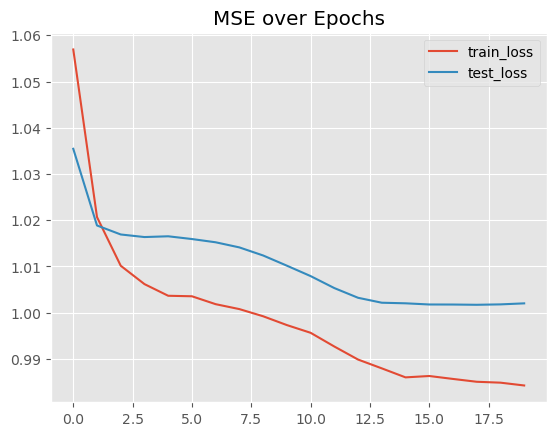

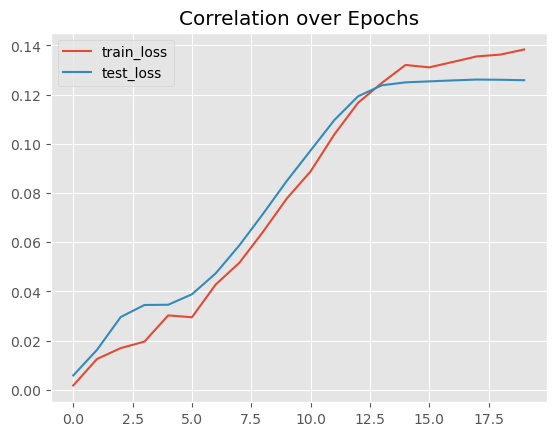

100%|██████████| 20/20 [00:06<00:00,  3.24it/s]


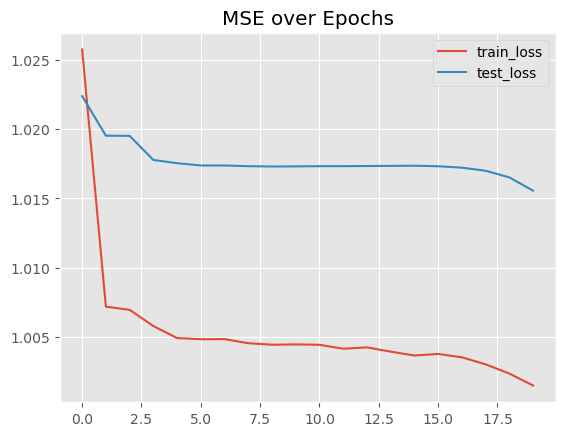

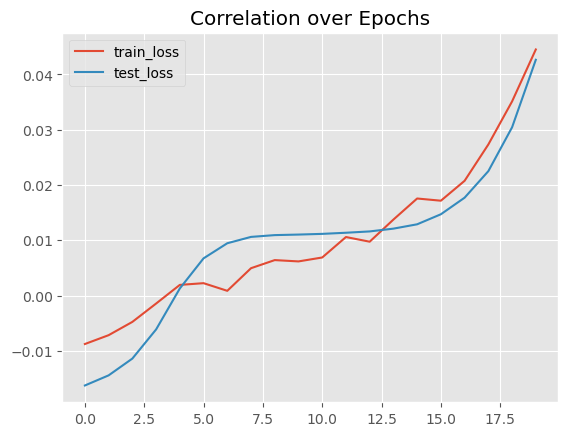

100%|██████████| 20/20 [00:34<00:00,  1.74s/it]


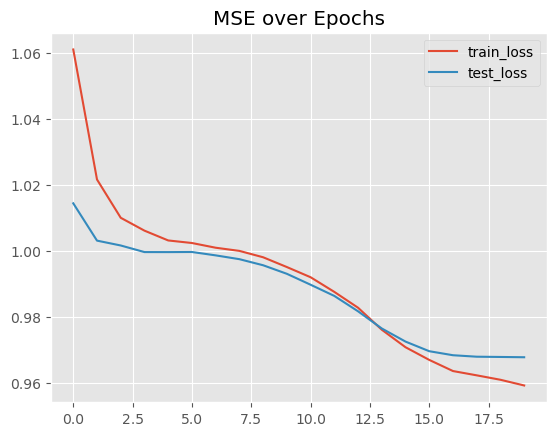

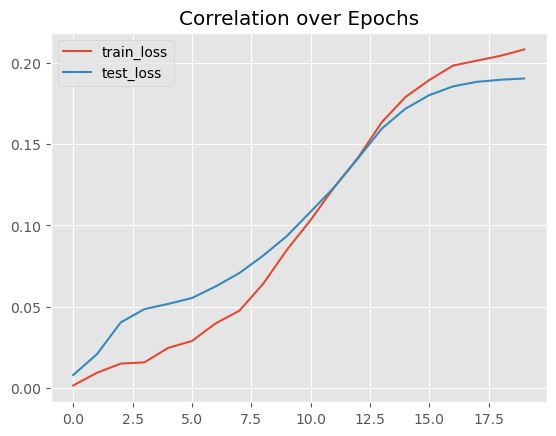

100%|██████████| 20/20 [00:04<00:00,  4.57it/s]


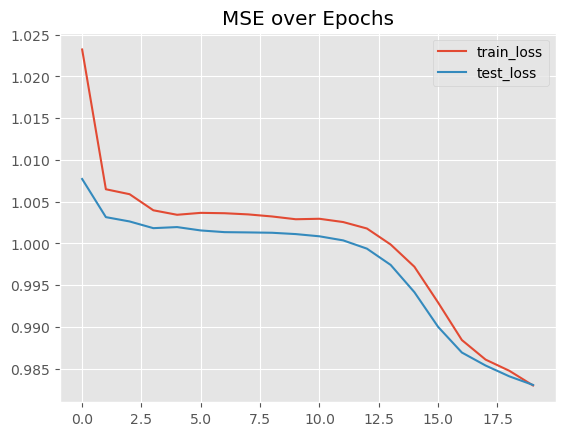

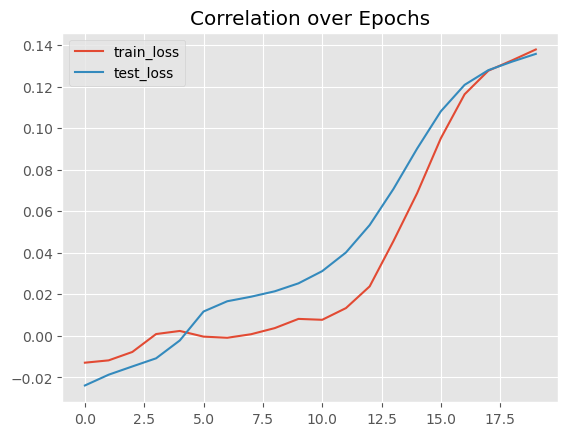

100%|██████████| 20/20 [00:34<00:00,  1.74s/it]


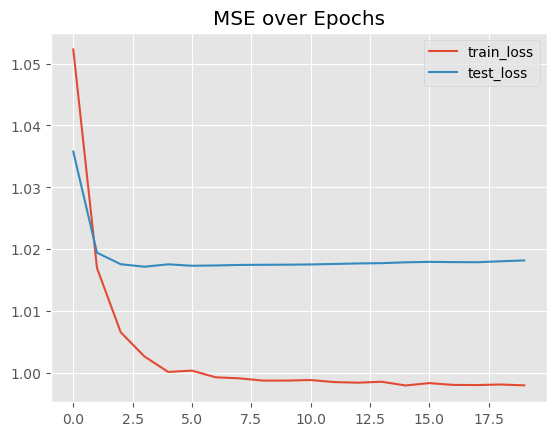

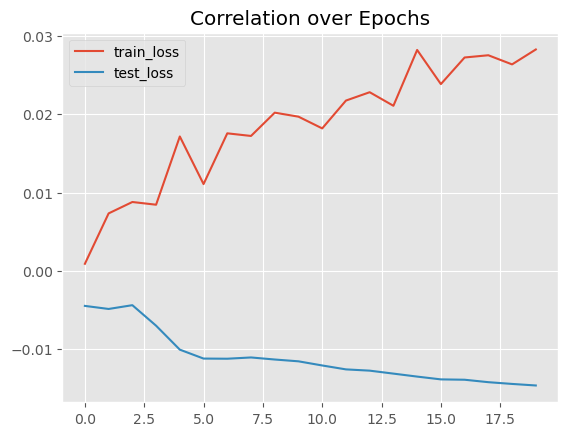

 40%|████      | 8/20 [00:02<00:03,  3.10it/s]


KeyboardInterrupt: 

In [31]:
def run_featurewise_static_routing_prototype(
    T=4000,
    n_ts=10,
    n_f=2,
    n_rolling=10,
    batch_size=256,
    seed=0,
):
    rho = 0.2
    cases = [
        {'case': f'TS_shift_rho_{rho:.2f}', 'effect': 'TS_shift', 'rho': rho},
        {'case': f'CS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'CS_shift', 'rho': rho},
        {'case': f'TSCS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'TSCS_shift', 'rho': rho},
    ]

    model_builders = {
        'TCTC': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=build_attention_mask(causal_mask, n_rolling, device=device),
            layers='TCTC', nhead=8, dropout=0.1, d_model=64, dim_feedforward=256,
            sparsify=None, roll_y=True, embeddings='both',
        ).to(device),
        'FeaturewiseStaticRouting': lambda: models.FeaturewiseStaticRoutingBiDimensionalModel(
            n_ts, n_f, n_rolling, d_model=64, dropout=0.1, roll_y=True, temperature=0.1,
        ).to(device),
    }

    results = []

    for case in cases:
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            rho=case['rho'],
            n_rolling=n_rolling,
            seed=seed,
            shuffle_cs=False,
        )

        train_loader, test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size, train_shuffle=False, test_shuffle=False
        )

        for model_name, build_model in model_builders.items():
            model = build_model()
            wrapper = torch_benchmarks.TorchWrapper(
                model,
                optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
                loss_fn=nn.MSELoss(),
                device=device,
            )
            wrapper.fit(train_loader, test_loader, epochs=20)

            results.append({
                'case': case['case'],
                'effect': case['effect'],
                'rho': case['rho'],
                'n_f': n_f,
                'model': model_name,
                'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
                'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
                'last_train_corr_noisy_y': wrapper.train_corr[-1] if wrapper.train_corr else None,
                'last_test_corr_noisy_y': wrapper.test_corr[-1] if wrapper.test_corr else None,
            })

    return pd.DataFrame(results)


featurewise_static_results = run_featurewise_static_routing_prototype()


In [ ]:
display(featurewise_static_results.style.format(precision=3))
display(
    featurewise_static_results
    .pivot(index='case', columns='model', values='test_corr_optimal')
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format(precision=3)
)


,case,effect,rho,n_f,model,train_corr_optimal,test_corr_optimal,last_train_corr_noisy_y,last_test_corr_noisy_y
0,TS_shift_rho_0.20,TS_shift,0.200,2,TCTC,0.757,0.750,0.138,0.126
1,TS_shift_rho_0.20,TS_shift,0.200,2,FeaturewiseStaticRouting,0.180,0.165,0.044,0.043
2,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,2,TCTC,0.946,0.945,0.208,0.190
3,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,2,FeaturewiseStaticRouting,0.648,0.652,0.138,0.136
4,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,2,TCTC,0.016,-0.001,0.028,-0.015
5,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,2,FeaturewiseStaticRouting,0.204,0.200,0.047,0.048


model,FeaturewiseStaticRouting,TCTC
case,,
CS_shift_rho_0.20_no_shuffle,0.652,0.945
TSCS_shift_rho_0.20_no_shuffle,0.200,-0.001
TS_shift_rho_0.20,0.165,0.750


## Prototype: routing-biased TCTC

This variant keeps the transformer attention mechanism but adds learned static routing priors to the temporal and cross-sectional attention scores.
It tests whether the routing signal that helped the static models can improve a more general transformer.


100%|██████████| 20/20 [00:50<00:00,  2.55s/it]


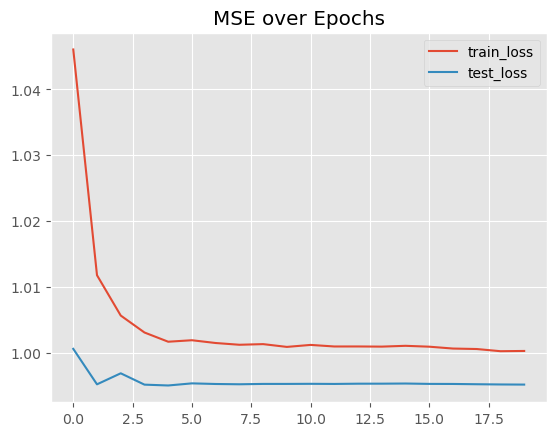

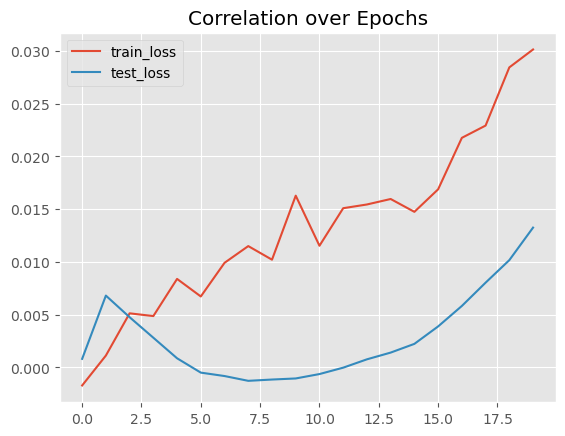

100%|██████████| 20/20 [01:28<00:00,  4.43s/it]


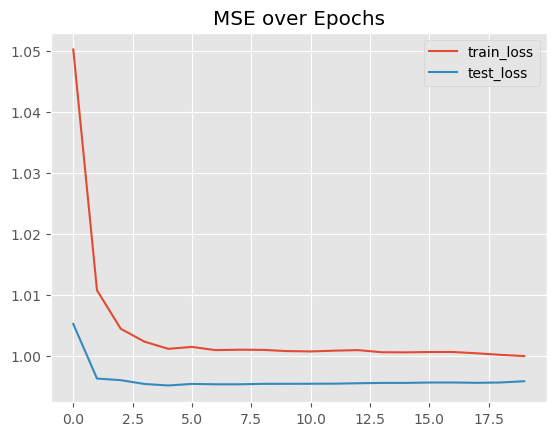

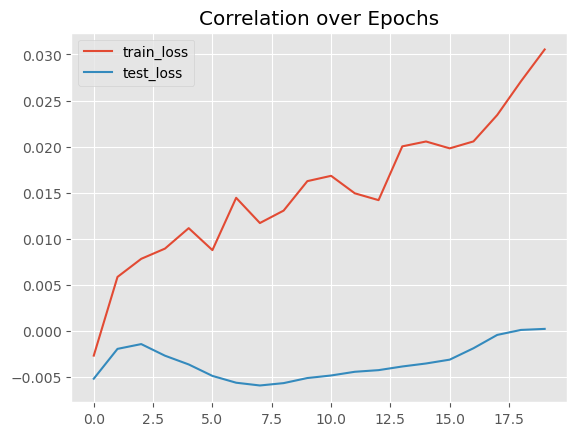

100%|██████████| 20/20 [00:27<00:00,  1.37s/it]


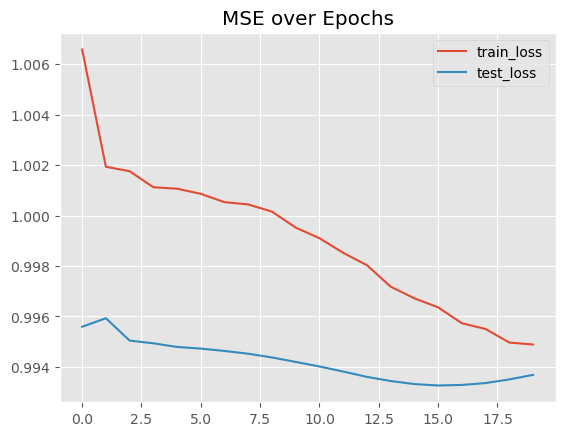

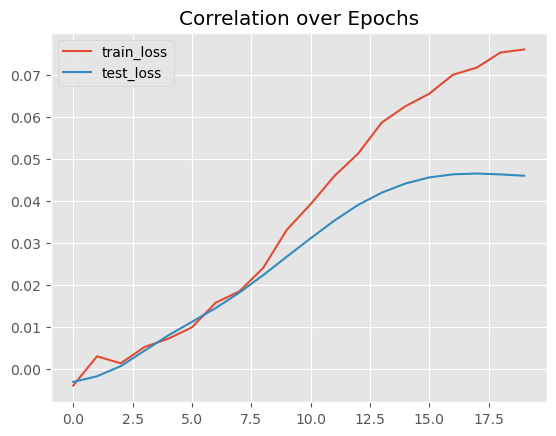

100%|██████████| 20/20 [00:53<00:00,  2.67s/it]


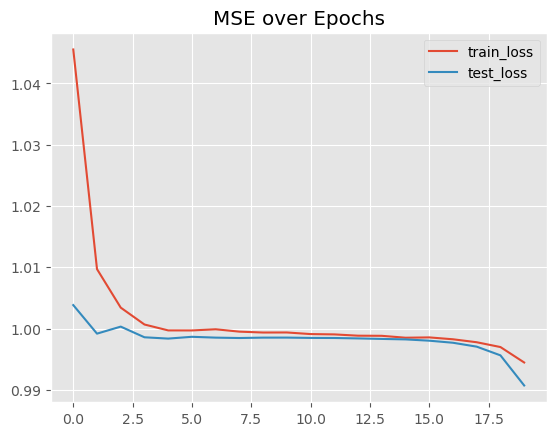

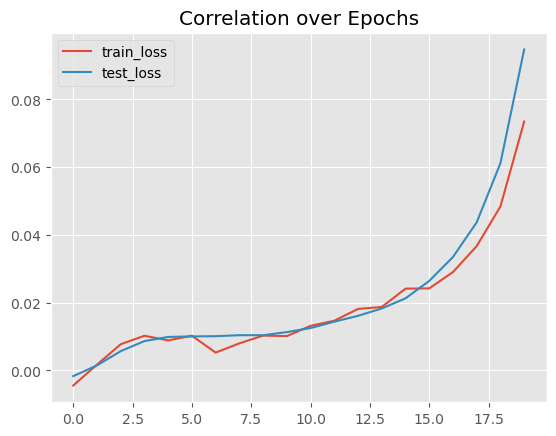

100%|██████████| 20/20 [00:53<00:00,  2.68s/it]


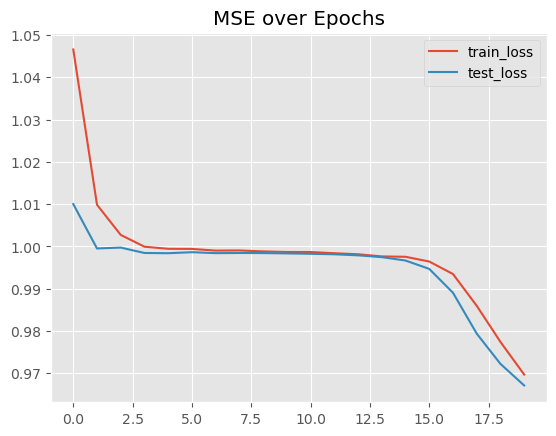

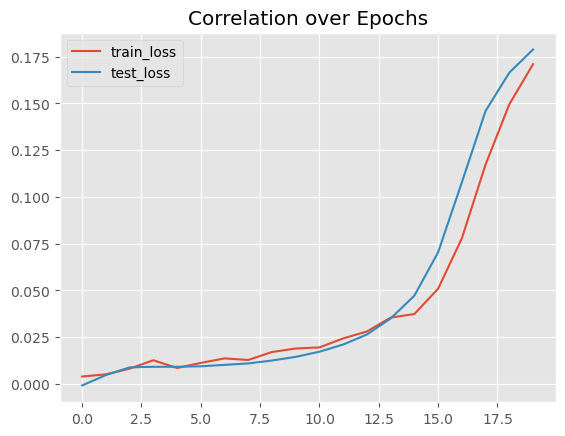

100%|██████████| 20/20 [00:08<00:00,  2.38it/s]


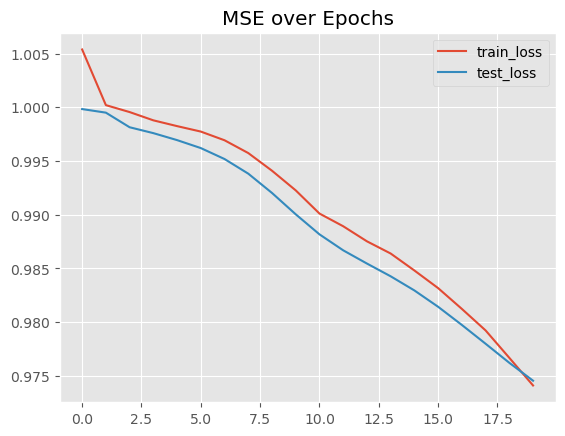

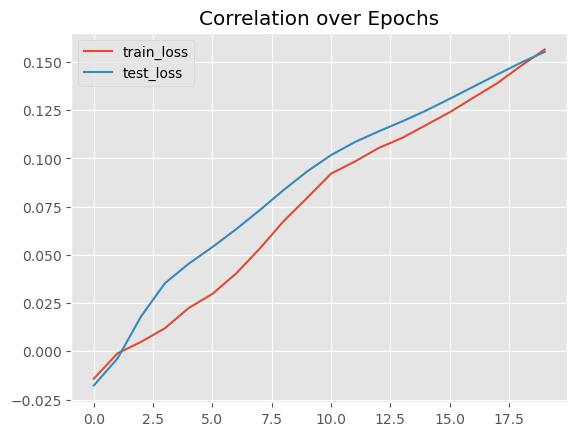

100%|██████████| 20/20 [00:46<00:00,  2.30s/it]


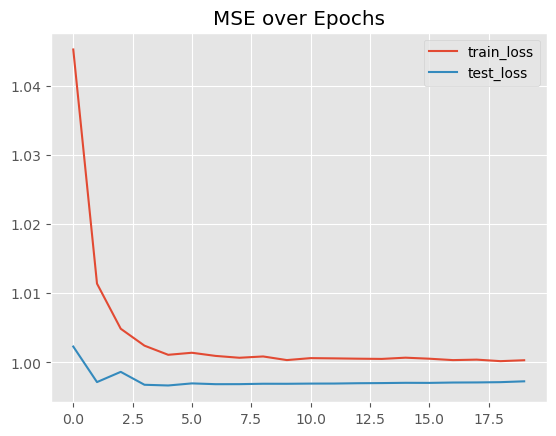

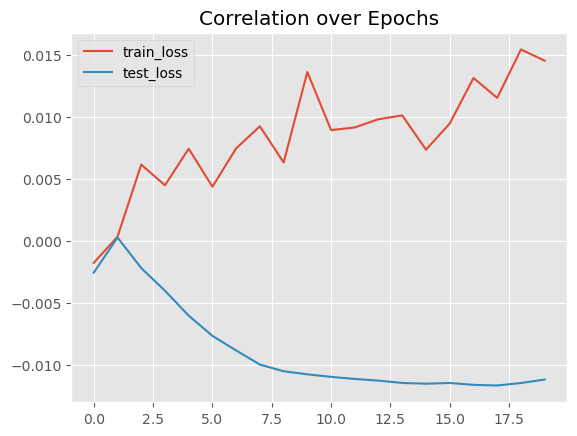

100%|██████████| 20/20 [00:50<00:00,  2.52s/it]


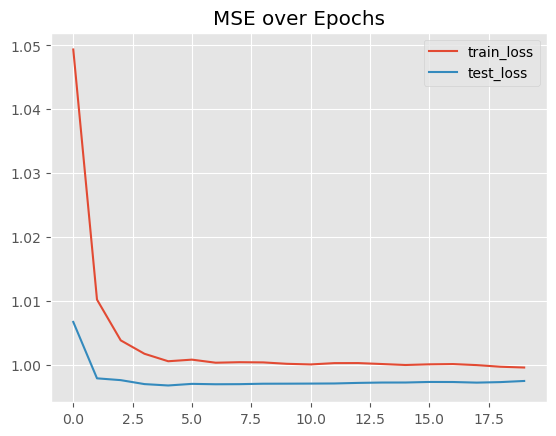

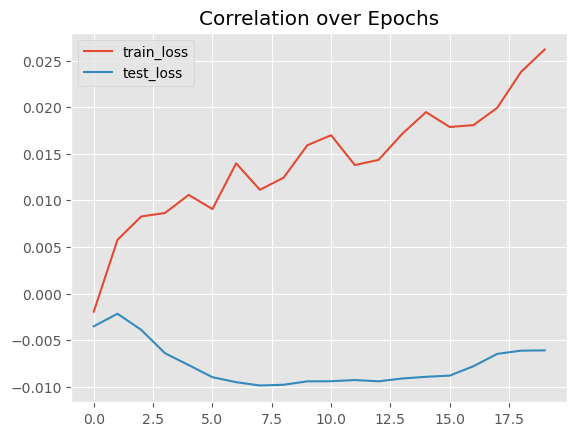

100%|██████████| 20/20 [00:11<00:00,  1.74it/s]


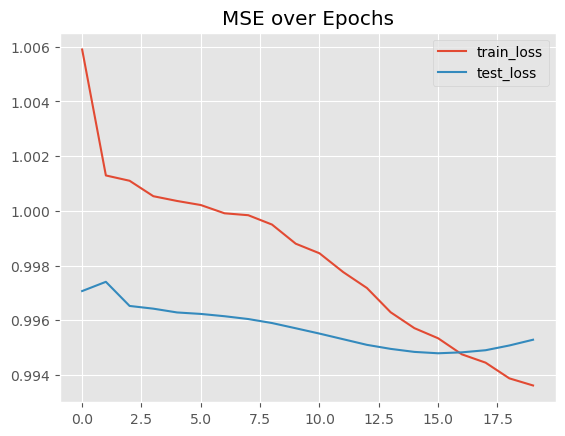

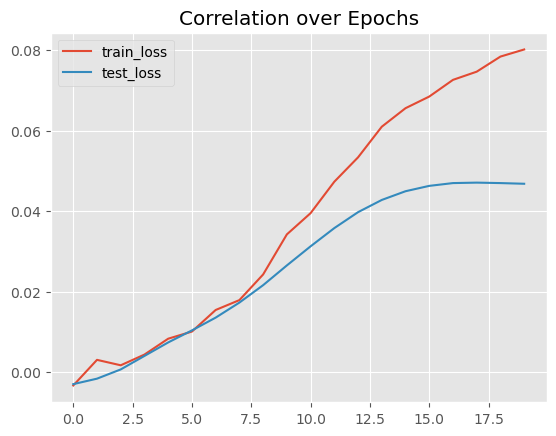

In [ ]:
def run_routing_biased_tctc_comparison(
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
    batch_size=256,
    seed=0,
):
    rho = 0.2
    cases = [
        {'case': f'TS_shift_rho_{rho:.2f}', 'effect': 'TS_shift', 'rho': rho},
        {'case': f'CS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'CS_shift', 'rho': rho},
        {'case': f'TSCS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'TSCS_shift', 'rho': rho},
    ]

    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    model_builders = {
        'TCTC': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c,
            layers='TCTC', nhead=8, dropout=0.1, d_model=64, dim_feedforward=256,
            sparsify=None, roll_y=True, embeddings='both',
        ).to(device),
        'RoutingBiased_TCTC': lambda: models.RoutingBiasedBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c,
            layers='TCTC', nhead=8, dropout=0.1, d_model=64, dim_feedforward=256,
            sparsify=None, roll_y=True, embeddings='both', temperature=1.0,
        ).to(device),
        'FeaturewiseStaticRouting': lambda: models.FeaturewiseStaticRoutingBiDimensionalModel(
            n_ts, n_f, n_rolling, d_model=64, dropout=0.1, roll_y=True, temperature=0.1,
        ).to(device),
    }

    results = []

    for case in cases:
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            rho=case['rho'],
            n_rolling=n_rolling,
            seed=seed,
            shuffle_cs=False,
        )

        train_loader, test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size, train_shuffle=False, test_shuffle=False
        )

        for model_name, build_model in model_builders.items():
            model = build_model()
            wrapper = torch_benchmarks.TorchWrapper(
                model,
                optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
                loss_fn=nn.MSELoss(),
                device=device,
            )
            wrapper.fit(train_loader, test_loader, epochs=20)

            results.append({
                'case': case['case'],
                'effect': case['effect'],
                'rho': case['rho'],
                'n_f': n_f,
                'model': model_name,
                "train_corr_optimal": corr_to_optimal(wrapper, train_loader, y_opt),
                "test_corr_optimal": corr_to_optimal(wrapper, test_loader, y_opt),
                "last_train_corr_noisy_y": wrapper.train_corr[-1] if wrapper.train_corr else None,
                "last_test_corr_noisy_y": wrapper.test_corr[-1] if wrapper.test_corr else None,
            })

    return pd.DataFrame(results)


routing_biased_tctc_results = run_routing_biased_tctc_comparison()


In [ ]:
display(routing_biased_tctc_results.style.format(precision=3))
display(
    routing_biased_tctc_results
    .pivot(index='case', columns='model', values='test_corr_optimal')
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format(precision=3)
)


,case,effect,rho,n_f,model,train_corr_optimal,test_corr_optimal,last_train_corr_noisy_y,last_test_corr_noisy_y
0,TS_shift_rho_0.20,TS_shift,0.200,5,TCTC,0.123,0.122,0.030,0.013
1,TS_shift_rho_0.20,TS_shift,0.200,5,RoutingBiased_TCTC,0.069,0.071,0.031,0.000
2,TS_shift_rho_0.20,TS_shift,0.200,5,FeaturewiseStaticRouting,0.354,0.347,0.076,0.046
3,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,5,TCTC,0.511,0.512,0.073,0.095
4,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,5,RoutingBiased_TCTC,0.886,0.883,0.171,0.179
5,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,5,FeaturewiseStaticRouting,0.736,0.734,0.156,0.155
6,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,5,TCTC,0.015,-0.003,0.015,-0.011
7,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,5,RoutingBiased_TCTC,0.015,0.001,0.026,-0.006
8,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,5,FeaturewiseStaticRouting,0.364,0.361,0.080,0.047


model,FeaturewiseStaticRouting,RoutingBiased_TCTC,TCTC
case,,,
CS_shift_rho_0.20_no_shuffle,0.734,0.883,0.512
TSCS_shift_rho_0.20_no_shuffle,0.361,0.001,-0.003
TS_shift_rho_0.20,0.347,0.071,0.122


100%|██████████| 40/40 [01:20<00:00,  2.01s/it]


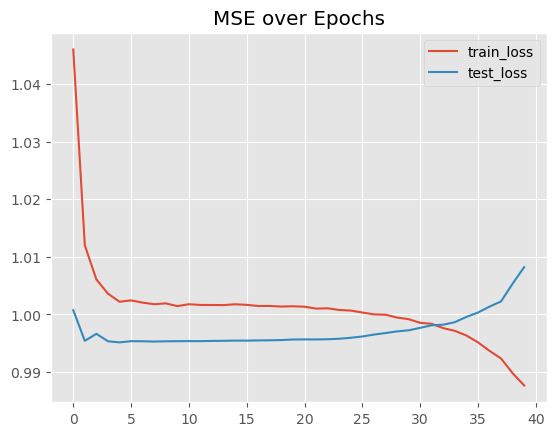

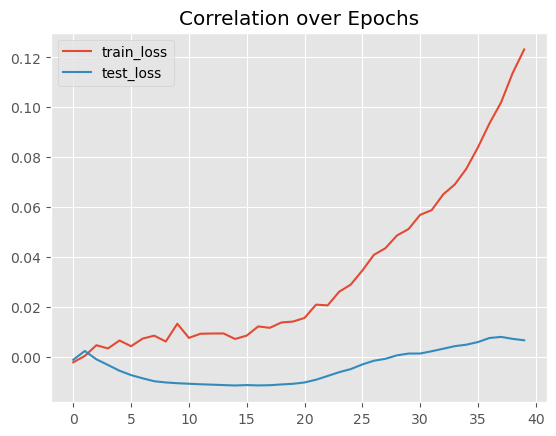

100%|██████████| 40/40 [01:39<00:00,  2.50s/it]


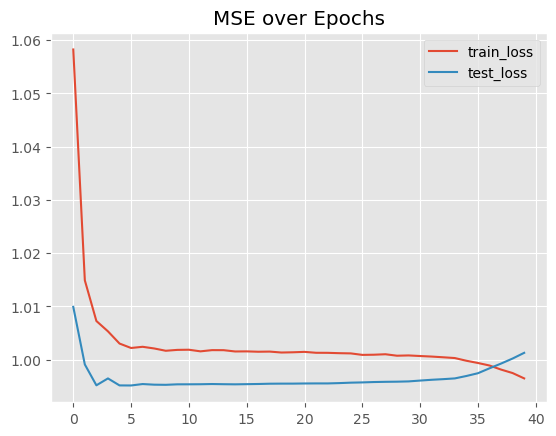

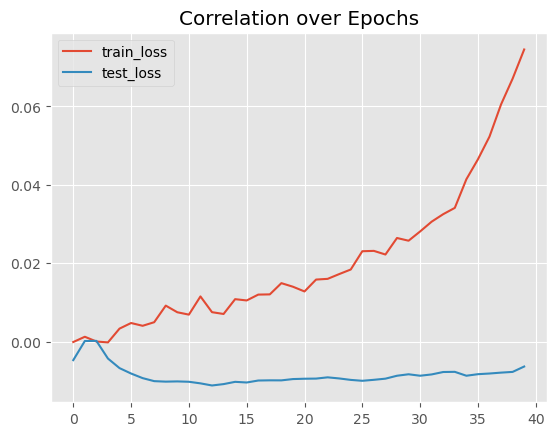

 60%|██████    | 24/40 [00:11<00:08,  1.86it/s]

In [ ]:
def run_routing_biased_tctc_comparison(
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
    batch_size=256,
    seed=0,
):
    rho = 0.03
    cases = [
        {'case': f'TS_shift_rho_{rho:.2f}', 'effect': 'TS_shift', 'rho': rho},
        {'case': f'CS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'CS_shift', 'rho': rho},
        {'case': f'TSCS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'TSCS_shift', 'rho': rho},
    ]

    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    model_builders = {
        'TCTC': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c,
            layers='TCTC', nhead=8, dropout=0.1, d_model=64, dim_feedforward=256,
            sparsify=None, roll_y=True, embeddings='both',
        ).to(device),
        'RoutingBiased_TCTC': lambda: models.RoutingBiasedBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c,
            layers='TCTC', nhead=8, dropout=0.1, d_model=64, dim_feedforward=256,
            sparsify=None, roll_y=True, embeddings='both', temperature=1.0,
        ).to(device),
        'FeaturewiseStaticRouting': lambda: models.FeaturewiseStaticRoutingBiDimensionalModel(
            n_ts, n_f, n_rolling, d_model=64, dropout=0.1, roll_y=True, temperature=0.1,
        ).to(device),
    }

    results = []

    for case in cases:
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            rho=case['rho'],
            n_rolling=n_rolling,
            seed=seed,
            shuffle_cs=False,
        )

        train_loader, test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size, train_shuffle=False, test_shuffle=False
        )

        for model_name, build_model in model_builders.items():
            model = build_model()
            wrapper = torch_benchmarks.TorchWrapper(
                model,
                optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
                loss_fn=nn.MSELoss(),
                device=device,
            )
            wrapper.fit(train_loader, test_loader, epochs=40)

            results.append({
                'case': case['case'],
                'effect': case['effect'],
                'rho': case['rho'],
                'n_f': n_f,
                'model': model_name,
                "train_corr_optimal": corr_to_optimal(wrapper, train_loader, y_opt),
                "test_corr_optimal": corr_to_optimal(wrapper, test_loader, y_opt),
                "last_train_corr_noisy_y": wrapper.train_corr[-1] if wrapper.train_corr else None,
                "last_test_corr_noisy_y": wrapper.test_corr[-1] if wrapper.test_corr else None,
            })

    return pd.DataFrame(results)


routing_biased_tctc_results = run_routing_biased_tctc_comparison()


In [ ]:
display(routing_biased_tctc_results.style.format(precision=3))
display(
    routing_biased_tctc_results
    .pivot(index='case', columns='model', values='test_corr_optimal')
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .format(precision=3)
)


,case,effect,rho,n_f,model,train_corr_optimal,test_corr_optimal,last_train_corr_noisy_y,last_test_corr_noisy_y
0,TS_shift_rho_0.20,TS_shift,0.200,5,TCTC,0.123,0.122,0.030,0.013
1,TS_shift_rho_0.20,TS_shift,0.200,5,RoutingBiased_TCTC,0.069,0.071,0.031,0.000
2,TS_shift_rho_0.20,TS_shift,0.200,5,FeaturewiseStaticRouting,0.354,0.347,0.076,0.046
3,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,5,TCTC,0.511,0.512,0.073,0.095
4,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,5,RoutingBiased_TCTC,0.886,0.883,0.171,0.179
5,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,5,FeaturewiseStaticRouting,0.736,0.734,0.156,0.155
6,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,5,TCTC,0.015,-0.003,0.015,-0.011
7,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,5,RoutingBiased_TCTC,0.015,0.001,0.026,-0.006
8,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,5,FeaturewiseStaticRouting,0.364,0.361,0.080,0.047


model,FeaturewiseStaticRouting,RoutingBiased_TCTC,TCTC
case,,,
CS_shift_rho_0.20_no_shuffle,0.734,0.883,0.512
TSCS_shift_rho_0.20_no_shuffle,0.361,0.001,-0.003
TS_shift_rho_0.20,0.347,0.071,0.122


## Simple Benchmark Helpers

These helpers build the same synthetic cases used elsewhere in the notebook and evaluate one model at a time.


In [12]:
def benchmark_cases(rho=0.2):
    return [
        {'case': f'TS_shift_rho_{rho:.2f}', 'effect': 'TS_shift', 'rho': rho},
        {'case': f'CS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'CS_shift', 'rho': rho},
        {'case': f'TSCS_shift_rho_{rho:.2f}_no_shuffle', 'effect': 'TSCS_shift', 'rho': rho},
    ]


def build_padded_rolling_windows(X, n_rolling):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    T, n_ts, n_f = X_np.shape
    windows = np.zeros((T, n_rolling, n_ts, n_f), dtype=np.float32)
    for t in range(T):
        start = max(0, t - n_rolling + 1)
        window = X_np[start:t + 1]
        windows[t, -window.shape[0]:] = window
    return windows


def corr_from_arrays(pred, target):
    pred = np.asarray(pred).reshape(-1)
    target = np.asarray(target).reshape(-1)
    return np.corrcoef(pred, target)[0, 1]


## Benchmark: Ridge Regression

A simple linear baseline on flattened rolling windows.


In [16]:
def run_ridge_benchmark(
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
    seed=0,
    alpha=1e-2,
):
    results = []
    for case in benchmark_cases(rho=0.2):
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            rho=case['rho'],
            n_rolling=n_rolling,
            seed=seed,
            shuffle_cs=False,
        )
        windows = build_padded_rolling_windows(X, n_rolling)
        X_flat = windows.reshape(T, -1)
        y_np = y.detach().cpu().numpy()
        y_opt_np = y_opt.detach().cpu().numpy()
        train_cut = int(T * 0.625)

        X_train = X_flat[:train_cut]
        X_test = X_flat[train_cut:]
        y_train = y_np[:train_cut]

        xtx = X_train.T @ X_train
        reg = alpha * np.eye(xtx.shape[0], dtype=X_train.dtype)
        w = np.linalg.solve(xtx + reg, X_train.T @ y_train)

        train_pred = X_train @ w
        test_pred = X_test @ w

        results.append({
            'case': case['case'],
            'effect': case['effect'],
            'rho': case['rho'],
            'model': 'Ridge',
            'train_corr_optimal': corr_from_arrays(train_pred, y_opt_np[:train_cut]),
            'test_corr_optimal': corr_from_arrays(test_pred, y_opt_np[train_cut:]),
        })

    return pd.DataFrame(results)


ridge_benchmark_results = run_ridge_benchmark()


In [17]:
display(ridge_benchmark_results.style.format(precision=3))


,case,effect,rho,model,train_corr_optimal,test_corr_optimal
0,TS_shift_rho_0.20,TS_shift,0.200,Ridge,0.413,0.368
1,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,Ridge,0.405,0.372
2,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,Ridge,0.409,0.367


## Benchmark: GlobalMLP

A simple global MLP on the full rolling window.


100%|██████████| 20/20 [00:02<00:00,  7.17it/s]


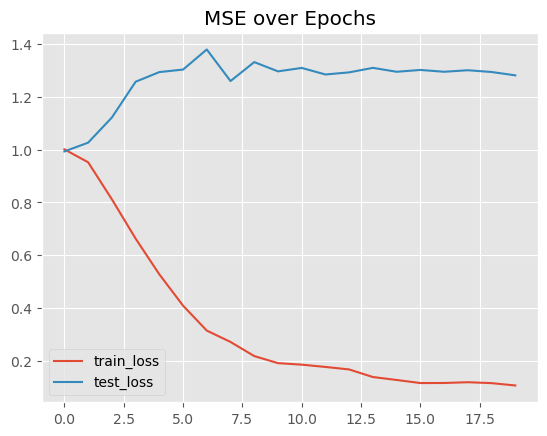

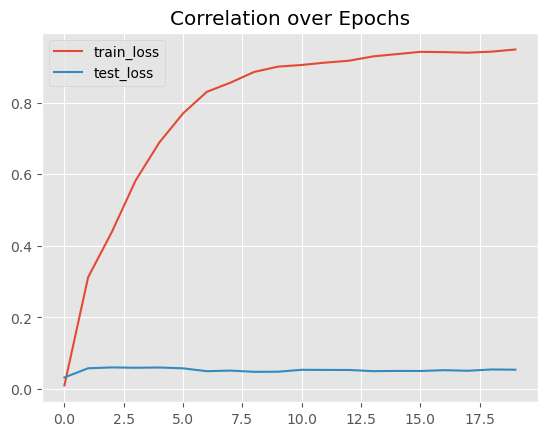

100%|██████████| 20/20 [00:02<00:00,  8.99it/s]


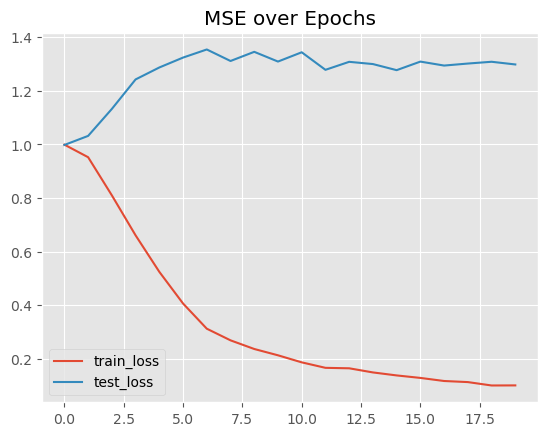

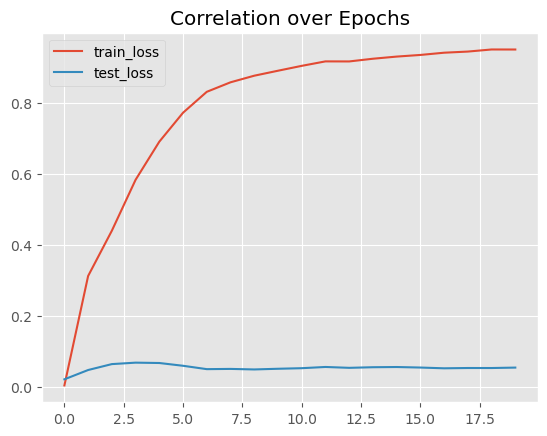

100%|██████████| 20/20 [00:02<00:00,  8.82it/s]


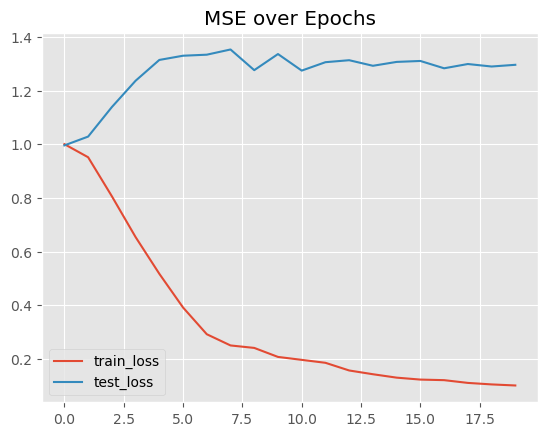

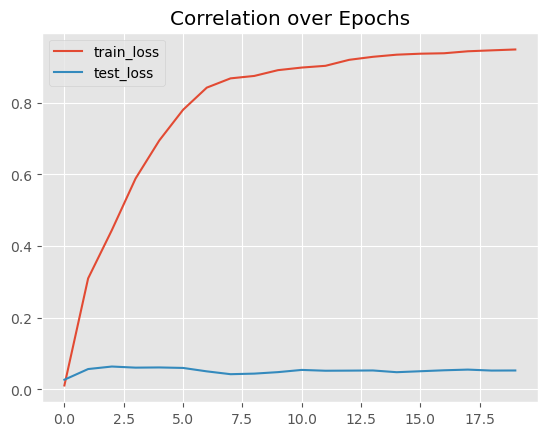

In [18]:
def run_global_mlp_benchmark(
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
    batch_size=256,
    seed=0,
):
    results = []
    for case in benchmark_cases(rho=0.2):
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            rho=case['rho'],
            n_rolling=n_rolling,
            seed=seed,
            shuffle_cs=False,
        )
        train_loader, test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size, train_shuffle=False, test_shuffle=False, roll_y=False
        )
        model = models.GlobalMLP(
            n_ts=n_ts, n_f=n_f, n_rolling=n_rolling, hidden_dim=512, num_layers=4, dropout=0.1,
        ).to(device)
        wrapper = torch_benchmarks.TorchWrapper(
            model, optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
            loss_fn=nn.MSELoss(), device=device,
        )
        wrapper.fit(train_loader, test_loader, epochs=20)
        results.append({
            'case': case['case'],
            'effect': case['effect'],
            'rho': case['rho'],
            'model': 'GlobalMLP',
            'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
            'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
        })
    return pd.DataFrame(results)


global_mlp_benchmark_results = run_global_mlp_benchmark()


In [19]:
display(global_mlp_benchmark_results.style.format(precision=3))


,case,effect,rho,model,train_corr_optimal,test_corr_optimal
0,TS_shift_rho_0.20,TS_shift,0.200,GlobalMLP,0.212,0.283
1,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,GlobalMLP,0.206,0.287
2,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,GlobalMLP,0.211,0.284


## Benchmark: BiDimensionalMLP

A structured MLP baseline that processes one axis and then the other.


100%|██████████| 20/20 [00:03<00:00,  5.36it/s]


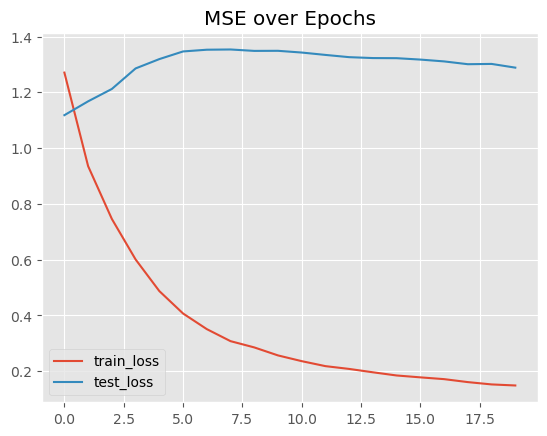

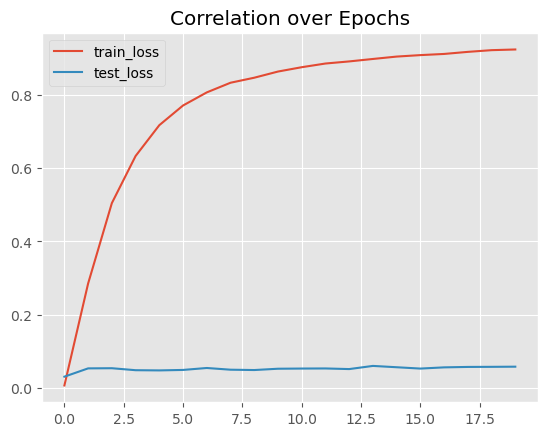

100%|██████████| 20/20 [00:03<00:00,  5.62it/s]


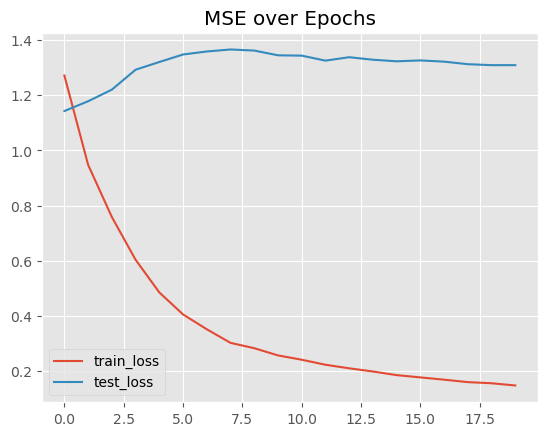

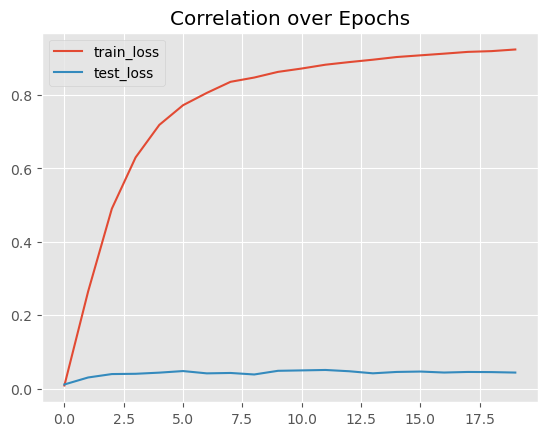

100%|██████████| 20/20 [00:03<00:00,  5.83it/s]


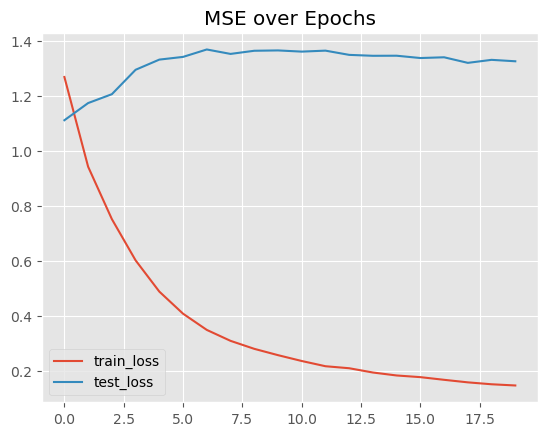

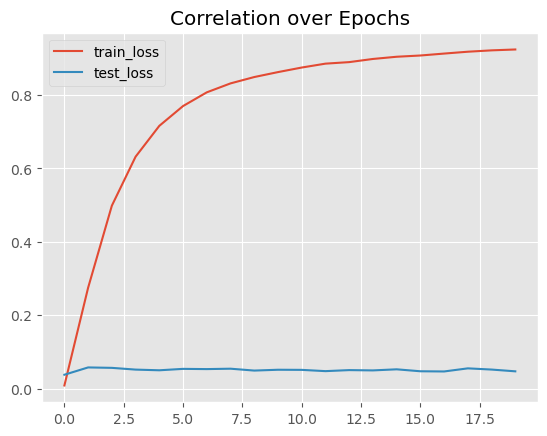

In [20]:
def run_bidimensional_mlp_benchmark(
    T=4000,
    n_ts=10,
    n_f=5,
    n_rolling=10,
    batch_size=256,
    seed=0,
):
    results = []
    for case in benchmark_cases(rho=0.2):
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T,
            n_ts=n_ts,
            n_f=n_f,
            rho=case['rho'],
            n_rolling=n_rolling,
            seed=seed,
            shuffle_cs=False,
        )
        train_loader, test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size, train_shuffle=False, test_shuffle=False, roll_y=False
        )
        model = models.BiDimensionalMLP(
            n_ts=n_ts, n_f=n_f, n_rolling=n_rolling, first_direction="T",
            hidden_dim_mlp1=256, hidden_dim_mlp2=512, num_layers_mlp1=3, num_layers_mlp2=3, dropout=0.1,
        ).to(device)
        wrapper = torch_benchmarks.TorchWrapper(
            model, optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
            loss_fn=nn.MSELoss(), device=device,
        )
        wrapper.fit(train_loader, test_loader, epochs=20)
        results.append({
            'case': case['case'],
            'effect': case['effect'],
            'rho': case['rho'],
            'model': 'BiDimensionalMLP',
            'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
            'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
        })
    return pd.DataFrame(results)


bidimensional_mlp_benchmark_results = run_bidimensional_mlp_benchmark()


In [21]:
display(bidimensional_mlp_benchmark_results.style.format(precision=3))


,case,effect,rho,model,train_corr_optimal,test_corr_optimal
0,TS_shift_rho_0.20,TS_shift,0.200,BiDimensionalMLP,0.192,0.249
1,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,BiDimensionalMLP,0.186,0.223
2,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,BiDimensionalMLP,0.188,0.248


## NeuralForecast Helpers

These helpers evaluate exogenous-input forecasting models one by one using rolling one-step prediction.
They use `X` as historical exogenous variables and keep the evaluation protocol close to the rest of the notebook.


In [13]:
from neuralforecast import NeuralForecast
from neuralforecast.models import TFT, TiDE, NBEATSx


def build_neuralforecast_xy_df(X, y):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
    T, n_ts, n_f = X_np.shape
    rows = []
    for s in range(n_ts):
        for t in range(T):
            row = {'unique_id': str(s), 'ds': int(t), 'y': float(y_np[t, s])}
            for f in range(n_f):
                row[f'x{f}'] = float(X_np[t, s, f])
            rows.append(row)
    return pd.DataFrame(rows)


def neuralforecast_hist_exog_corrs(model_builder, X, y, y_opt, train_pct=0.625, train_eval_steps=100, test_eval_steps=200):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    y_opt_np = y_opt.detach().cpu().numpy() if torch.is_tensor(y_opt) else np.asarray(y_opt)
    T, n_ts, n_f = X_np.shape
    train_cut = int(T * train_pct)
    full_df = build_neuralforecast_xy_df(X, y)
    hist_exog_list = [f'x{f}' for f in range(n_f)]

    train_df = full_df[full_df['ds'] < train_cut].copy()
    model = model_builder(n_series=n_ts, hist_exog_list=hist_exog_list)
    nf = NeuralForecast(models=[model], freq=1)
    nf.fit(train_df, val_size=0)

    def rollout_corr(start_t, end_t):
        pred_steps = []
        for t in range(start_t, end_t):
            hist_df = full_df[full_df['ds'] < t].copy()
            pred_t = nf.predict(df=hist_df)
            model_col = [c for c in pred_t.columns if c not in ['unique_id', 'ds']][0]
            pred_t = pred_t.sort_values(['ds', 'unique_id'])
            pred_steps.append(pred_t[model_col].to_numpy())
        pred_values = np.stack(pred_steps, axis=0)
        target_values = y_opt_np[start_t:end_t]
        pred_flat = pred_values.reshape(-1)
        target_flat = target_values.reshape(-1)
        finite_mask = np.isfinite(pred_flat) & np.isfinite(target_flat)
        if finite_mask.sum() < 2:
            return np.nan
        pred_used = pred_flat[finite_mask]
        target_used = target_flat[finite_mask]
        if np.std(pred_used) == 0 or np.std(target_used) == 0:
            return 0.0
        return np.corrcoef(pred_used, target_used)[0, 1]

    warmup = max(n_f, 10)
    train_start = min(train_cut - 1, warmup)
    train_end = min(train_cut, train_start + train_eval_steps)
    test_start = train_cut
    test_end = min(T, test_start + test_eval_steps)

    return {
        'train_corr_optimal': rollout_corr(train_start, train_end),
        'test_corr_optimal': rollout_corr(test_start, test_end),
    }


def default_nf_trainer_kwargs():
    return dict(
        accelerator='auto',
        devices=1,
        enable_progress_bar=False,
        logger=False,
    )


## Benchmark: TFT

Temporal Fusion Transformer with `X` used as historical exogenous inputs.


In [23]:
def run_tft_benchmark(T=4000, n_ts=10, n_f=5, n_rolling=10, seed=0):
    results = []
    for case in benchmark_cases(rho=0.2):
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T, n_ts=n_ts, n_f=n_f, rho=case['rho'], n_rolling=n_rolling, seed=seed, shuffle_cs=False,
        )
        corrs = neuralforecast_hist_exog_corrs(
            model_builder=lambda n_series, hist_exog_list: TFT(
                h=1, input_size=n_rolling, hist_exog_list=hist_exog_list,
                hidden_size=64, n_head=4, dropout=0.1, max_steps=100, val_check_steps=20,
                learning_rate=1e-3, scaler_type='identity', random_seed=seed,
                **default_nf_trainer_kwargs(),
            ),
            X=X, y=y, y_opt=y_opt, train_pct=0.625, test_eval_steps=200,
        )
        results.append({
            'case': case['case'],
            'effect': case['effect'],
            'rho': case['rho'],
            'model': 'TFT',
            'train_corr_optimal': corrs['train_corr_optimal'],
            'test_corr_optimal': corrs['test_corr_optimal'],
        })
    return pd.DataFrame(results)


tft_benchmark_results = run_tft_benchmark()


Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    896 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  262 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │ 64.8 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │     65 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 328 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 328 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 128                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    896 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  262 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │ 64.8 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │     65 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 328 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 328 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 128                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    896 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  262 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │ 64.8 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │     65 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 328 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 328 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 128                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [24]:
display(tft_benchmark_results.style.format(precision=3))


,case,effect,rho,model,train_corr_optimal,test_corr_optimal
0,TS_shift_rho_0.20,TS_shift,0.200,TFT,0.134,0.159
1,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,TFT,0.011,0.028
2,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,TFT,0.080,0.028


## Benchmark: TiDE

TiDE with `X` used as historical exogenous inputs.


In [25]:
def run_tide_benchmark(T=4000, n_ts=10, n_f=5, n_rolling=10, seed=0):
    results = []
    for case in benchmark_cases(rho=0.2):
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T, n_ts=n_ts, n_f=n_f, rho=case['rho'], n_rolling=n_rolling, seed=seed, shuffle_cs=False,
        )
        corrs = neuralforecast_hist_exog_corrs(
            model_builder=lambda n_series, hist_exog_list: TiDE(
                h=1, input_size=n_rolling, hist_exog_list=hist_exog_list,
                exclude_insample_y=False,
                hidden_size=256, dropout=0.1, max_steps=100, val_check_steps=20,
                learning_rate=1e-3, scaler_type='identity', random_seed=seed,
                **default_nf_trainer_kwargs(),
            ),
            X=X, y=y, y_opt=y_opt, train_pct=0.625, test_eval_steps=200,
        )
        results.append({
            'case': case['case'],
            'effect': case['effect'],
            'rho': case['rho'],
            'model': 'TiDE',
            'train_corr_optimal': corrs['train_corr_optimal'],
            'test_corr_optimal': corrs['test_corr_optimal'],
        })
    return pd.DataFrame(results)


tide_benchmark_results = run_tide_benchmark()


Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                 │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train         │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler               │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_exog_projection │ MLPResidual   │  2.6 K │ train │     0 │
│ 4 │ dense_encoder        │ Sequential    │ 92.4 K │ train │     0 │
│ 5 │ dense_decoder        │ Sequential    │ 82.3 K │ train │     0 │
│ 6 │ temporal_decoder     │ MLPResidual   │  4.4 K │ train │     0 │
│ 7 │ global_skip          │ Linear        │     11 │ train │     0 │
└───┴──────────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 181 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 181 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_fu

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                 │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train         │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler               │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_exog_projection │ MLPResidual   │  2.6 K │ train │     0 │
│ 4 │ dense_encoder        │ Sequential    │ 92.4 K │ train │     0 │
│ 5 │ dense_decoder        │ Sequential    │ 82.3 K │ train │     0 │
│ 6 │ temporal_decoder     │ MLPResidual   │  4.4 K │ train │     0 │
│ 7 │ global_skip          │ Linear        │     11 │ train │     0 │
└───┴──────────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 181 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 181 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_fu

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                 │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train         │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler               │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_exog_projection │ MLPResidual   │  2.6 K │ train │     0 │
│ 4 │ dense_encoder        │ Sequential    │ 92.4 K │ train │     0 │
│ 5 │ dense_decoder        │ Sequential    │ 82.3 K │ train │     0 │
│ 6 │ temporal_decoder     │ MLPResidual   │  4.4 K │ train │     0 │
│ 7 │ global_skip          │ Linear        │     11 │ train │     0 │
└───┴──────────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 181 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 181 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cyrilgarcia/miniconda3/envs/cyril10/lib/python3.10/site-packages/numpy/lib/_fu

In [26]:
display(tide_benchmark_results.style.format(precision=3))


,case,effect,rho,model,train_corr_optimal,test_corr_optimal
0,TS_shift_rho_0.20,TS_shift,0.200,TiDE,nan,nan
1,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,TiDE,nan,nan
2,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,TiDE,nan,nan


## Benchmark: NBEATSx

NBEATSx with `X` used as historical exogenous inputs.


In [27]:
def run_nbeatsx_benchmark(T=4000, n_ts=10, n_f=5, n_rolling=10, seed=0):
    results = []
    for case in benchmark_cases(rho=0.2):
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'],
            T=T, n_ts=n_ts, n_f=n_f, rho=case['rho'], n_rolling=n_rolling, seed=seed, shuffle_cs=False,
        )
        corrs = neuralforecast_hist_exog_corrs(
            model_builder=lambda n_series, hist_exog_list: NBEATSx(
                h=1, input_size=n_rolling, hist_exog_list=hist_exog_list,
                exclude_insample_y=True,
                stack_types=['identity', 'identity', 'identity'],
                mlp_units=[[256, 256], [256, 256], [256, 256]], max_steps=100, val_check_steps=20,
                learning_rate=1e-3, scaler_type='identity', random_seed=seed,
                **default_nf_trainer_kwargs(),
            ),
            X=X, y=y, y_opt=y_opt, train_pct=0.625, test_eval_steps=200,
        )
        results.append({
            'case': case['case'],
            'effect': case['effect'],
            'rho': case['rho'],
            'model': 'NBEATSx',
            'train_corr_optimal': corrs['train_corr_optimal'],
            'test_corr_optimal': corrs['test_corr_optimal'],
        })
    return pd.DataFrame(results)


nbeatsx_benchmark_results = run_nbeatsx_benchmark()


Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  647 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 647 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 647 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  647 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 647 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 647 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  647 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 647 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 647 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [28]:
display(nbeatsx_benchmark_results.style.format(precision=3))


,case,effect,rho,model,train_corr_optimal,test_corr_optimal
0,TS_shift_rho_0.20,TS_shift,0.200,NBEATSx,0.748,0.781
1,CS_shift_rho_0.20_no_shuffle,CS_shift,0.200,NBEATSx,0.071,0.016
2,TSCS_shift_rho_0.20_no_shuffle,TSCS_shift,0.200,NBEATSx,0.058,0.007


## Final Comparison

This section is the clean comparison point. Change the parameters below and rerun this section to evaluate all selected models on exactly the same synthetic setup.
BiDimensionalMLP is omitted for now because it is too close in spirit to GlobalMLP.


In [21]:
final_cmp_params = {
    'T': 4000,
    'n_ts': 10,
    'n_f': 10,
    'n_rolling': 10,
    'rho': 0.1,
    'seed': 0,
    'batch_size': 256,
    'torch_epochs': 20,
    'nf_test_eval_steps': 200,
}


100%|██████████| 20/20 [01:11<00:00,  3.59s/it]


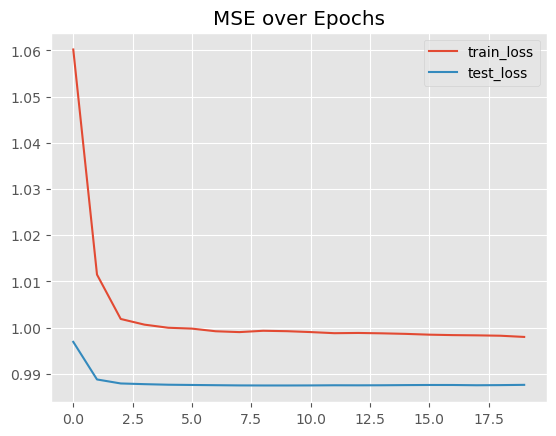

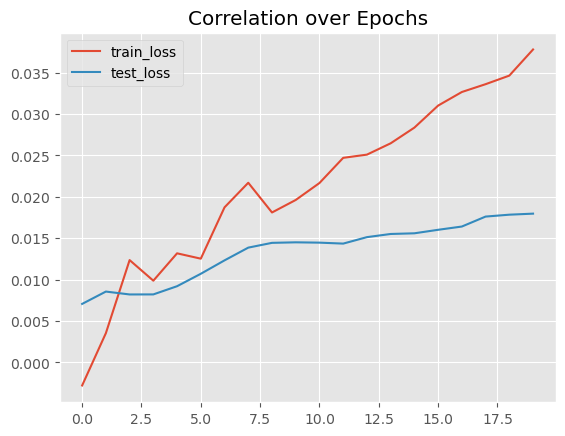

100%|██████████| 20/20 [00:58<00:00,  2.93s/it]


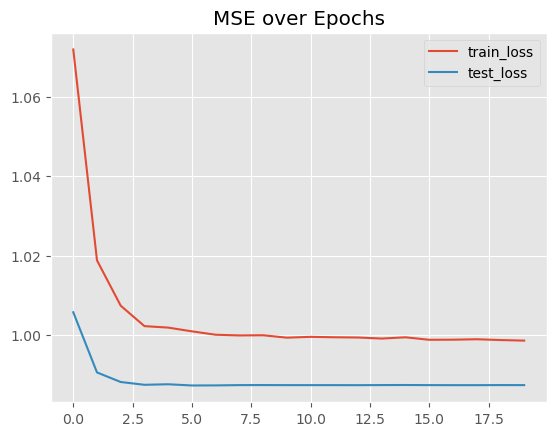

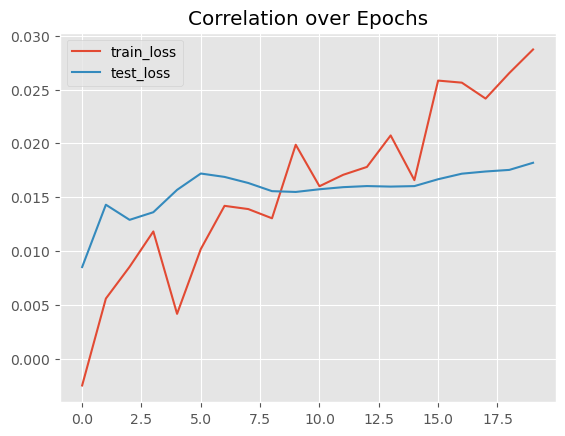

100%|██████████| 20/20 [00:10<00:00,  1.91it/s]


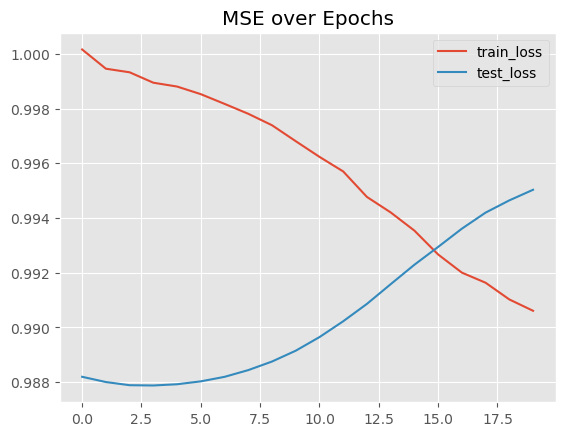

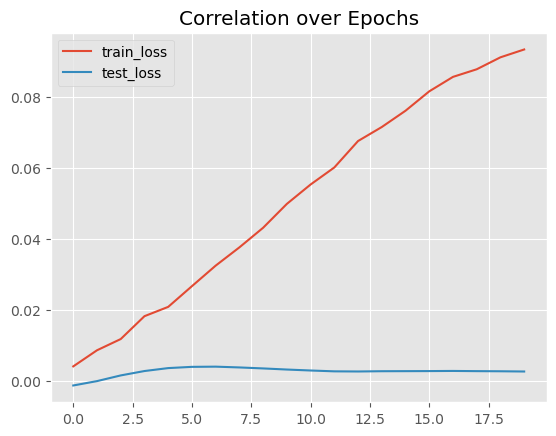

100%|██████████| 20/20 [00:07<00:00,  2.55it/s]


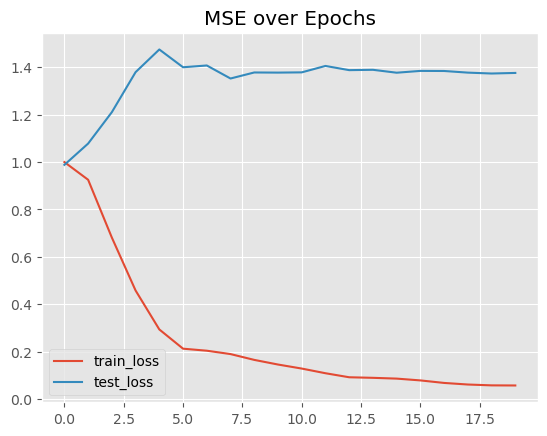

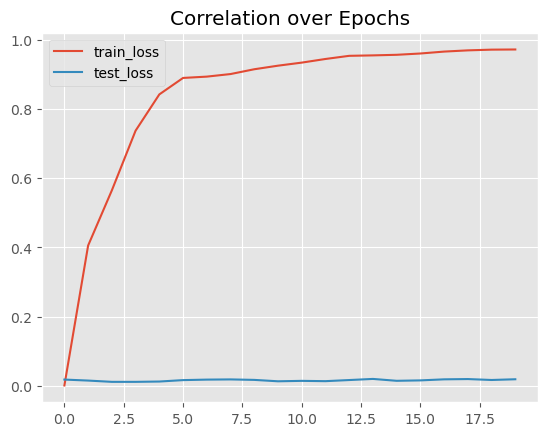

Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │  1.5 K │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  373 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │ 64.8 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │     65 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 440 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 440 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 168                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                 │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train         │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler               │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_exog_projection │ MLPResidual   │  3.9 K │ train │     0 │
│ 4 │ dense_encoder        │ Sequential    │ 92.4 K │ train │     0 │
│ 5 │ dense_decoder        │ Sequential    │ 82.3 K │ train │     0 │
│ 6 │ temporal_decoder     │ MLPResidual   │  4.4 K │ train │     0 │
│ 7 │ global_skip          │ Linear        │     11 │ train │     0 │
└───┴──────────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 183 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 183 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  685 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 685 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 685 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
100%|██████████| 20/20 [00:44<00:00,  2.22s/it]


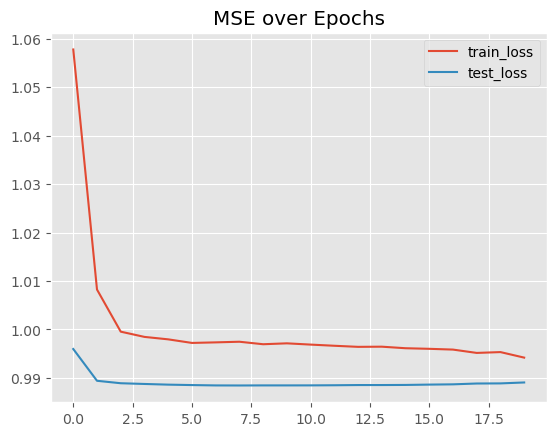

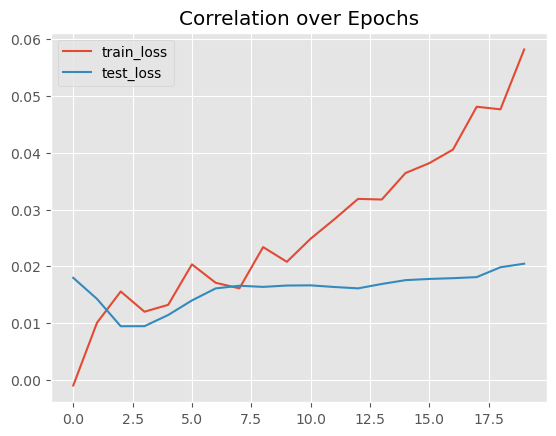

100%|██████████| 20/20 [00:59<00:00,  2.98s/it]


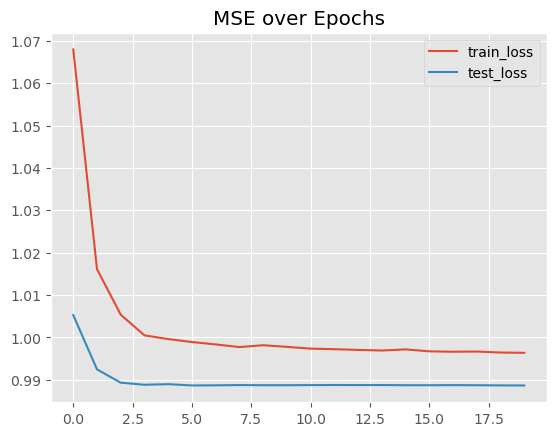

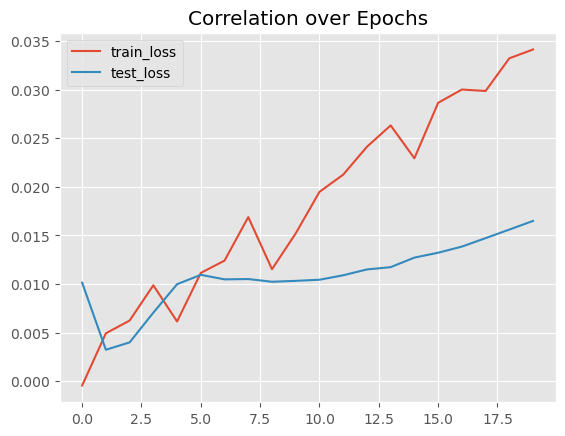

100%|██████████| 20/20 [00:14<00:00,  1.38it/s]


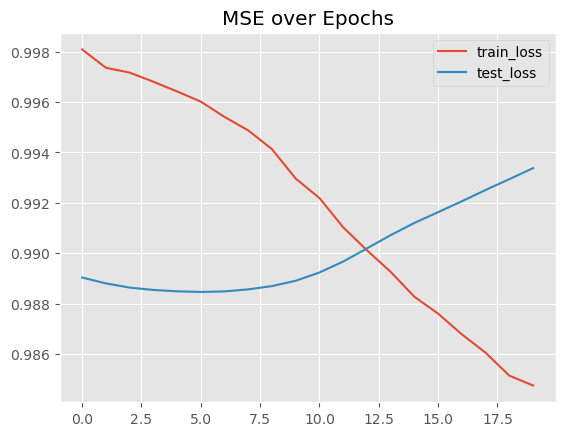

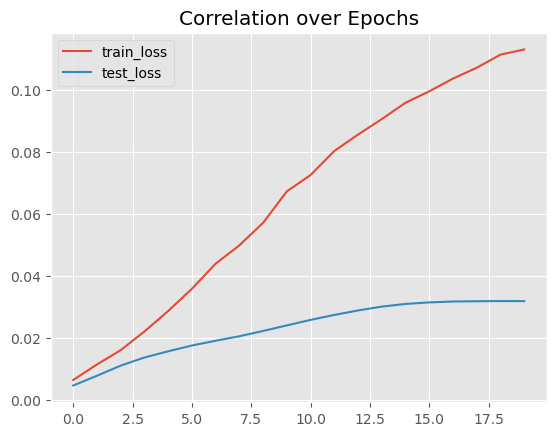

100%|██████████| 20/20 [00:05<00:00,  3.56it/s]


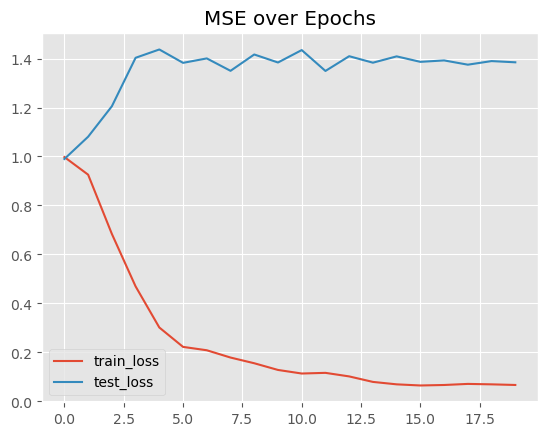

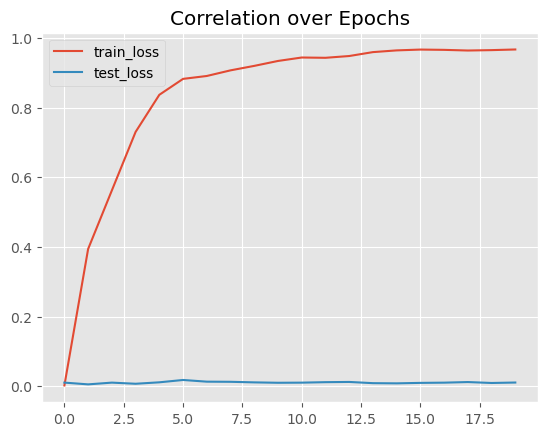

Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │  1.5 K │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  373 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │ 64.8 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │     65 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 440 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 440 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 168                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                 │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train         │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler               │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_exog_projection │ MLPResidual   │  3.9 K │ train │     0 │
│ 4 │ dense_encoder        │ Sequential    │ 92.4 K │ train │     0 │
│ 5 │ dense_decoder        │ Sequential    │ 82.3 K │ train │     0 │
│ 6 │ temporal_decoder     │ MLPResidual   │  4.4 K │ train │     0 │
│ 7 │ global_skip          │ Linear        │     11 │ train │     0 │
└───┴──────────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 183 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 183 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  685 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 685 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 685 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
100%|██████████| 20/20 [00:47<00:00,  2.39s/it]


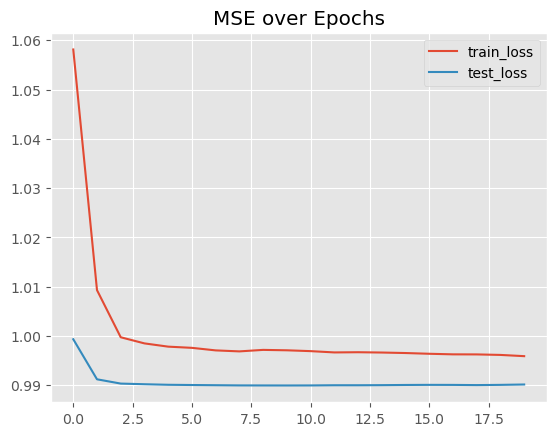

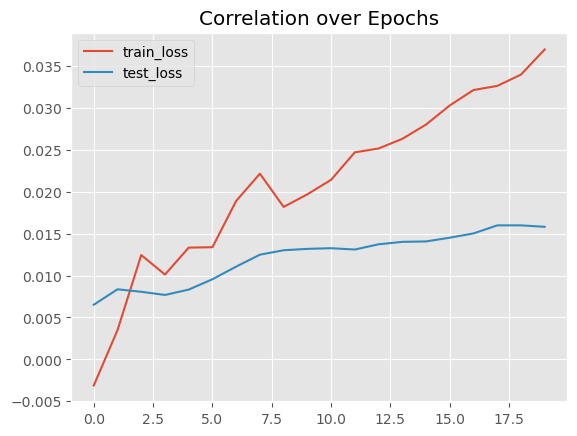

100%|██████████| 20/20 [00:56<00:00,  2.81s/it]


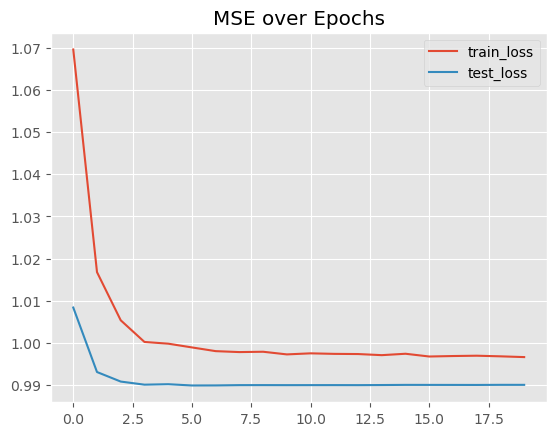

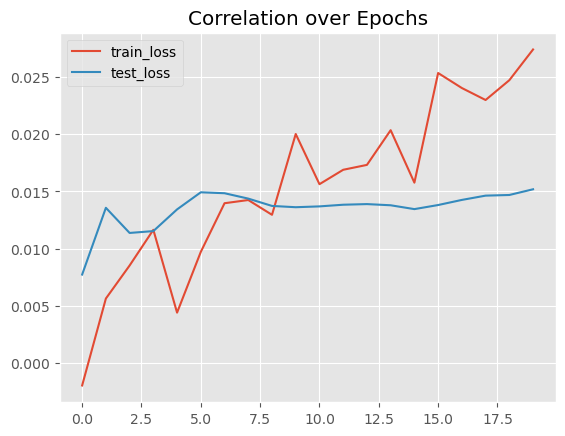

100%|██████████| 20/20 [00:10<00:00,  1.94it/s]


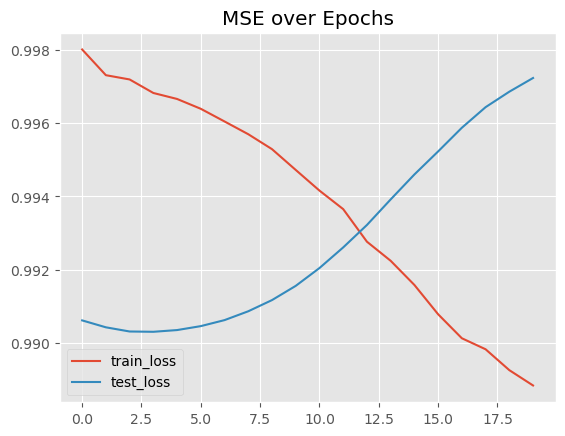

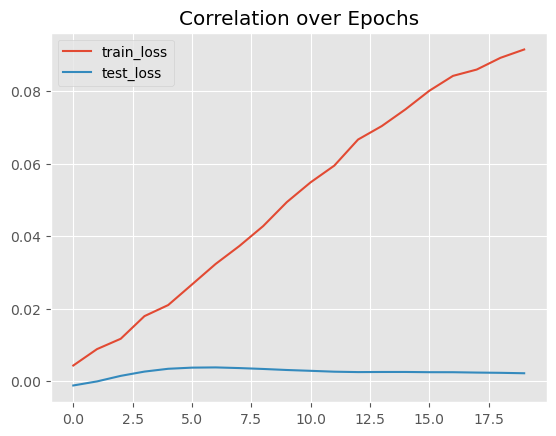

100%|██████████| 20/20 [00:07<00:00,  2.77it/s]


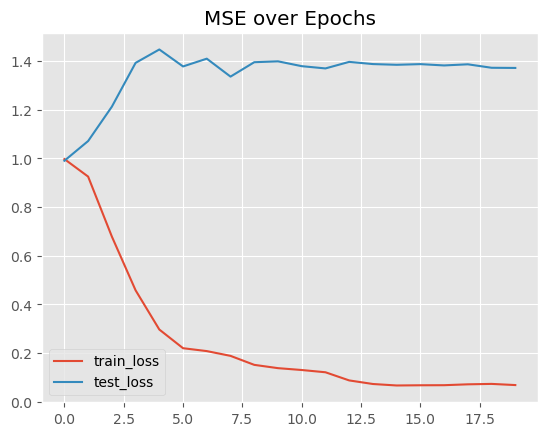

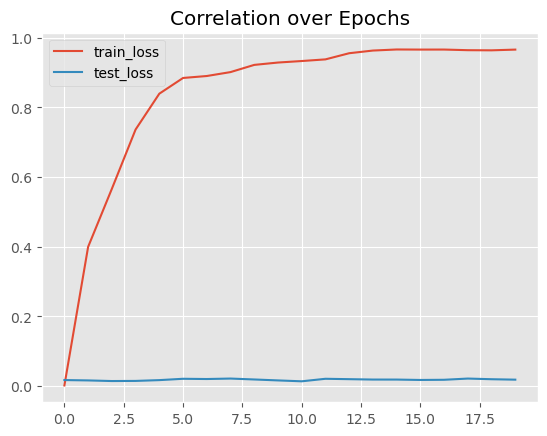

Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │  1.5 K │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  373 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │ 64.8 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │     65 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 440 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 440 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 168                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                 │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train         │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler               │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_exog_projection │ MLPResidual   │  3.9 K │ train │     0 │
│ 4 │ dense_encoder        │ Sequential    │ 92.4 K │ train │     0 │
│ 5 │ dense_decoder        │ Sequential    │ 82.3 K │ train │     0 │
│ 6 │ temporal_decoder     │ MLPResidual   │  4.4 K │ train │     0 │
│ 7 │ global_skip          │ Linear        │     11 │ train │     0 │
└───┴──────────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 183 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 183 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

In [ ]:
def run_final_comparison(params):
    T = params['T']
    n_ts = params['n_ts']
    n_f = params['n_f']
    n_rolling = params['n_rolling']
    rho = params['rho']
    seed = params['seed']
    batch_size = params['batch_size']
    torch_epochs = params['torch_epochs']
    nf_test_eval_steps = params['nf_test_eval_steps']

    cases = benchmark_cases(rho=rho)
    mask_c = build_attention_mask(causal_mask, n_rolling, device=device)
    results = []

    torch_model_builders = {
        'TCTC': lambda: models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None,
            roll_y=True, embeddings='both',
        ).to(device),
        'RoutingBiased_TCTC': lambda: models.RoutingBiasedBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None,
            roll_y=True, embeddings='both', temperature=1.0,
        ).to(device),
        'FeaturewiseStaticRouting': lambda: models.FeaturewiseStaticRoutingBiDimensionalModel(
            n_ts, n_f, n_rolling, d_model=64, dropout=0.1, roll_y=True, temperature=0.1,
        ).to(device),
        'GlobalMLP': lambda: models.GlobalMLP(
            n_ts=n_ts, n_f=n_f, n_rolling=n_rolling, hidden_dim=512, num_layers=4, dropout=0.1,
        ).to(device),
    }

    def append_torch_result(model_name, wrapper, train_loader, test_loader, y_opt):
        results.append({
            'model': model_name,
            'train_corr_optimal': corr_to_optimal(wrapper, train_loader, y_opt),
            'test_corr_optimal': corr_to_optimal(wrapper, test_loader, y_opt),
        })

    for case in cases:
        X, y, y_opt, _ = generate_project_generator_dataset(
            effect=case['effect'], T=T, n_ts=n_ts, n_f=n_f, rho=case['rho'],
            n_rolling=n_rolling, seed=seed, shuffle_cs=True,
        )

        # Ridge
        windows = build_padded_rolling_windows(X, n_rolling)
        X_flat = windows.reshape(T, -1)
        y_np = y.detach().cpu().numpy()
        y_opt_np = y_opt.detach().cpu().numpy()
        train_cut = int(T * 0.625)
        X_train = X_flat[:train_cut]
        X_test = X_flat[train_cut:]
        y_train = y_np[:train_cut]
        xtx = X_train.T @ X_train
        reg = 1e-2 * np.eye(xtx.shape[0], dtype=X_train.dtype)
        w = np.linalg.solve(xtx + reg, X_train.T @ y_train)
        train_pred = X_train @ w
        test_pred = X_test @ w
        case_results = [{
            'case': case['case'],
            'effect': case['effect'],
            'rho': case['rho'],
            'model': 'Ridge',
            'train_corr_optimal': corr_from_arrays(train_pred, y_opt_np[:train_cut]),
            'test_corr_optimal': corr_from_arrays(test_pred, y_opt_np[train_cut:]),
        }]

        # Torch models with rolling outputs
        rolling_train_loader, rolling_test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size, train_shuffle=False, test_shuffle=False, roll_y=True
        )
        flat_train_loader, flat_test_loader = build_loaders_from_tensors(
            X, y, n_rolling=n_rolling, batch_size=batch_size, train_shuffle=False, test_shuffle=False, roll_y=False
        )

        for model_name, build_model in torch_model_builders.items():
            model = build_model()
            wrapper = torch_benchmarks.TorchWrapper(
                model, optimizer=torch.optim.AdamW(model.parameters(), lr=0.001),
                loss_fn=nn.MSELoss(), device=device,
            )
            if model_name == "GlobalMLP":
                wrapper.fit(flat_train_loader, flat_test_loader, epochs=torch_epochs)
                case_results.append({
                    'case': case['case'], 'effect': case['effect'], 'rho': case['rho'], 'model': model_name,
                    'train_corr_optimal': corr_to_optimal(wrapper, flat_train_loader, y_opt),
                    'test_corr_optimal': corr_to_optimal(wrapper, flat_test_loader, y_opt),
                })
            else:
                wrapper.fit(rolling_train_loader, rolling_test_loader, epochs=torch_epochs)
                case_results.append({
                    'case': case['case'], 'effect': case['effect'], 'rho': case['rho'], 'model': model_name,
                    'train_corr_optimal': corr_to_optimal(wrapper, rolling_train_loader, y_opt),
                    'test_corr_optimal': corr_to_optimal(wrapper, rolling_test_loader, y_opt),
                })

        # NeuralForecast models
        nf_specs = [
            ('TFT', lambda n_series, hist_exog_list: TFT(
                h=1, input_size=n_rolling, hist_exog_list=hist_exog_list, hidden_size=64, n_head=4, dropout=0.1,
                max_steps=100, val_check_steps=20, learning_rate=1e-3, scaler_type='identity', random_seed=seed,
                **default_nf_trainer_kwargs(),
            )),
            ('TiDE', lambda n_series, hist_exog_list: TiDE(
                h=1, input_size=n_rolling, hist_exog_list=hist_exog_list, exclude_insample_y=False, hidden_size=256, dropout=0.1,
                max_steps=100, val_check_steps=20, learning_rate=1e-3, scaler_type='identity', random_seed=seed,
                **default_nf_trainer_kwargs(),
            )),
            ('NBEATSx', lambda n_series, hist_exog_list: NBEATSx(
                h=1, input_size=n_rolling, hist_exog_list=hist_exog_list, exclude_insample_y=True,
                stack_types=['identity', 'identity', 'identity'], mlp_units=[[256, 256], [256, 256], [256, 256]],
                max_steps=100, val_check_steps=20, learning_rate=1e-3, scaler_type='identity', random_seed=seed,
                **default_nf_trainer_kwargs(),
            )),
        ]
        for model_name, model_builder in nf_specs:
            corrs = neuralforecast_hist_exog_corrs(
                model_builder=model_builder, X=X, y=y, y_opt=y_opt, train_pct=0.625, test_eval_steps=nf_test_eval_steps
            )
            case_results.append({
                'case': case['case'], 'effect': case['effect'], 'rho': case['rho'], 'model': model_name,
                'train_corr_optimal': corrs['train_corr_optimal'], 'test_corr_optimal': corrs['test_corr_optimal'],
            })

        results.extend(case_results)

    return pd.DataFrame(results).sort_values(['case', 'model']).reset_index(drop=True)


final_comparison_results = run_final_comparison(final_cmp_params)


In [ ]:
display(final_comparison_results.style.format(precision=3))
display(
    final_comparison_results
    .pivot(index='case', columns='model', values='test_corr_optimal')
    .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1, axis=1)
    .format(precision=3)
)


,case,effect,rho,model,train_corr_optimal,test_corr_optimal
0,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,FeaturewiseStaticRouting,0.403,0.417
1,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,GlobalMLP,0.096,0.118
2,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,NBEATSx,0.023,0.005
3,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,Ridge,0.148,0.115
4,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,RoutingBiased_TCTC,0.039,0.047
5,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,TCTC,0.090,0.093
6,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,TFT,0.067,-0.014
7,CS_shift_rho_0.10_no_shuffle,CS_shift,0.100,TiDE,nan,nan
8,TSCS_shift_rho_0.10_no_shuffle,TSCS_shift,0.100,FeaturewiseStaticRouting,0.100,0.094
9,TSCS_shift_rho_0.10_no_shuffle,TSCS_shift,0.100,GlobalMLP,0.091,0.120


model,FeaturewiseStaticRouting,GlobalMLP,NBEATSx,Ridge,RoutingBiased_TCTC,TCTC,TFT,TiDE
case,,,,,,,,
CS_shift_rho_0.10_no_shuffle,0.417,0.118,0.005,0.115,0.047,0.093,-0.014,nan
TSCS_shift_rho_0.10_no_shuffle,0.094,0.120,-0.039,0.127,-0.006,0.001,-0.009,nan
TS_shift_rho_0.10,0.092,0.126,0.336,0.119,0.019,0.013,0.256,nan
